In [ ]:
library(Seurat)
library(SeuratWrappers)
library(dplyr)
library(ggplot2)
library(usethis)
library(devtools)
library(harmony)
library(patchwork)
library(ggplot2)
library(gridExtra)
library(jcolors)
library(MetBrewer)
library(readxl)

options(repr.plot.width = 14, repr.plot.height = 28)


Warning message:
“package ‘Seurat’ was built under R version 4.5.2”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.5.2”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Loading required package: Rcpp

Warning message:
“package ‘Rcpp’ was built under R version 4.5.2”

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [2]:
setwd("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data")
timecourse <- readRDS("Timecourse.rds")

In [6]:
# Check metadata columns to find the time variable
colnames(timecourse@meta.data)


[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "dataset"        
 [5] "percent.mt"      "S.Score"         "G2M.Score"       "Phase"          
 [9] "old.ident"       "RNA_snn_res.1"   "seurat_clusters" "RNA_snn_res.0.6"
[13] "cluster.ids"     "class3"          "day"

In [4]:
table(timecourse$orig.ident)
table(timecourse$dataset)



HB4_D11 HB4_D16 HB4_D21 HB4_D30  HB4_D5  HB4_D7 
   4912    6571    7962    7950    5481    8183 


 HB4 D5  HB4 D7 HB4 D11 HB4 D16 HB4 D21 HB4 D30 
   5481    8183    4912    6571    7962    7950 

In [ ]:
# Create a clean "day" column
timecourse$day <- as.numeric(gsub("HB4_D", "", timecourse$orig.ident))

# Load integrin genes from the Excel sheet
ecm_genes <- read_excel("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data/presel_genes.xlsx", sheet = 2)
integrin_genes <- na.omit(ecm_genes$Integrins)

# Check which integrins are actually in the dataset
integrin_genes <- integrin_genes[integrin_genes %in% rownames(timecourse)]
print(integrin_genes)


# there are 26 i

 [1] "ITGA1"  "ITGA2"  "ITGA3"  "ITGA4"  "ITGA5"  "ITGA6"  "ITGA7"  "ITGA8" 
 [9] "ITGA9"  "ITGA10" "ITGA11" "ITGAE"  "ITGAL"  "ITGAM"  "ITGAV"  "ITGA2B"
[17] "ITGAX"  "ITGB1"  "ITGB2"  "ITGB3"  "ITGB4"  "ITGB5"  "ITGB7"  "ITGB8" 


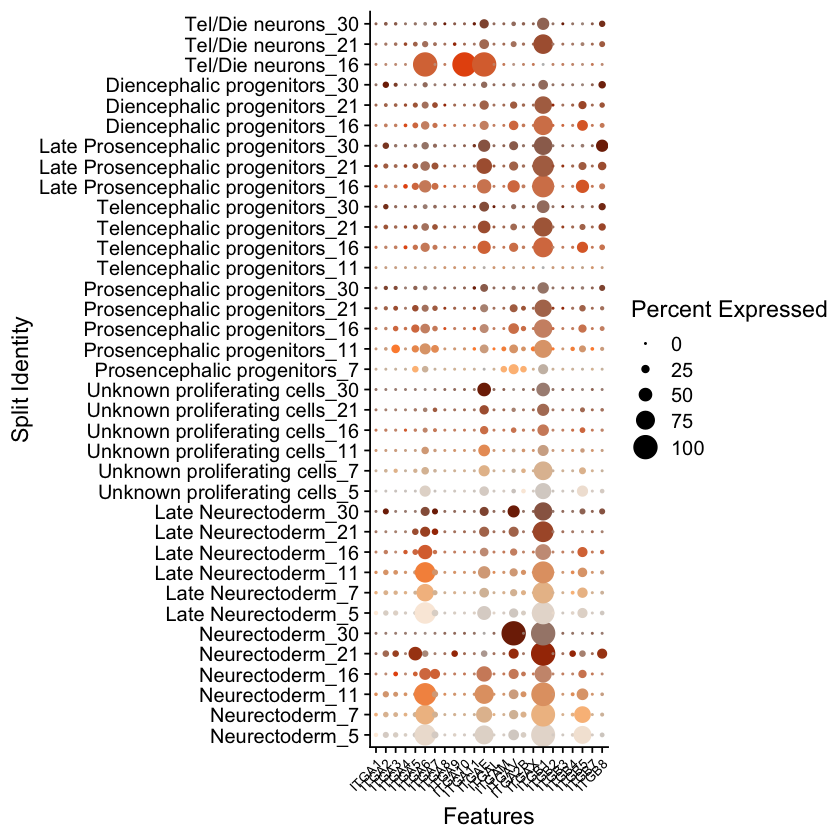

In [31]:
DotPlot(timecourse, features = integrin_genes, group.by = "class3", split.by = "day",
    cols = c("#feedde", "#fdbe85", "#fd8d3c", "#e6550d", "#a63603", "#7f2704")) +    
  RotatedAxis() +
  theme(axis.text.x = element_text(size = 8))


- there are 26 integrin genes in Akansha list but only 24 of thiose are in the dataset. only ITGB6 and ITGAD are missing
- next I want to create a stacked bar plot of cell type proportions among cells expressign a given integrin across timepoints. 

### Un-weighted stacked plot (absolute total expression)

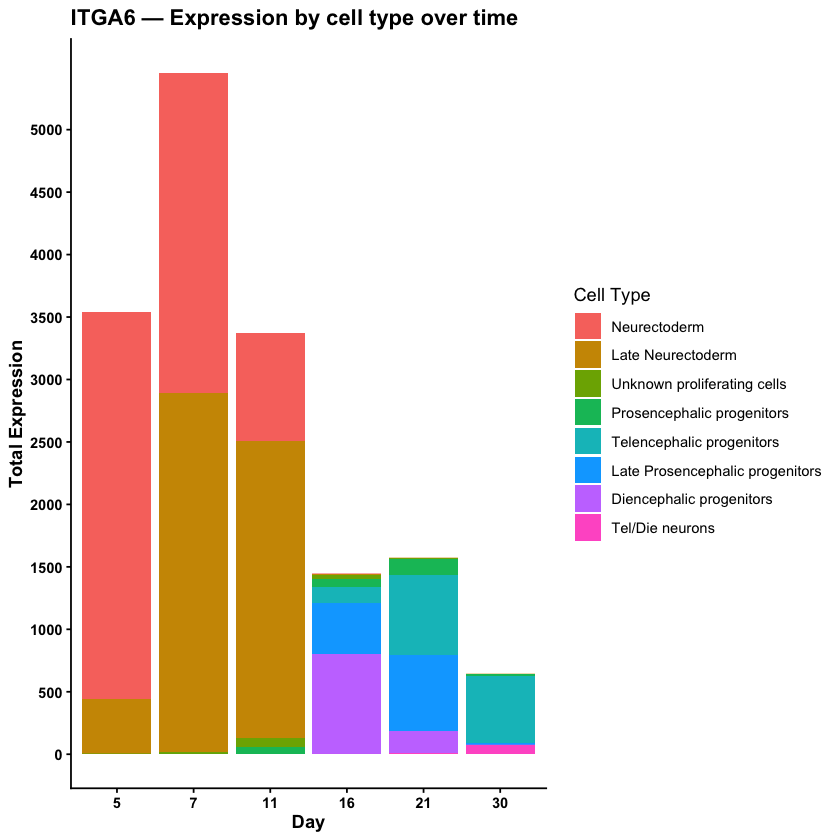

In [ ]:
# I start with ITGA6 since it is one of the most broadly expressed

gene <- "ITGA6"

expr <- GetAssayData(timecourse, layer = "data")[gene, ]
meta <- timecourse@meta.data
meta$expr <- expr

# Sum expression per day per cell type
expr_sum <- meta %>%
  group_by(day, class3) %>%
  summarise(total_expr = sum(expr), .groups = "drop")

ggplot(expr_sum, aes(x = factor(day), y = total_expr, fill = class3)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(breaks = seq(0, 5000, 500)) +
  labs(title = paste(gene, "— Expression by cell type over time"),
       x = "Day", y = "Total Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold")
  )



### Weighted dodge plot (mean expr withing each day and class group)

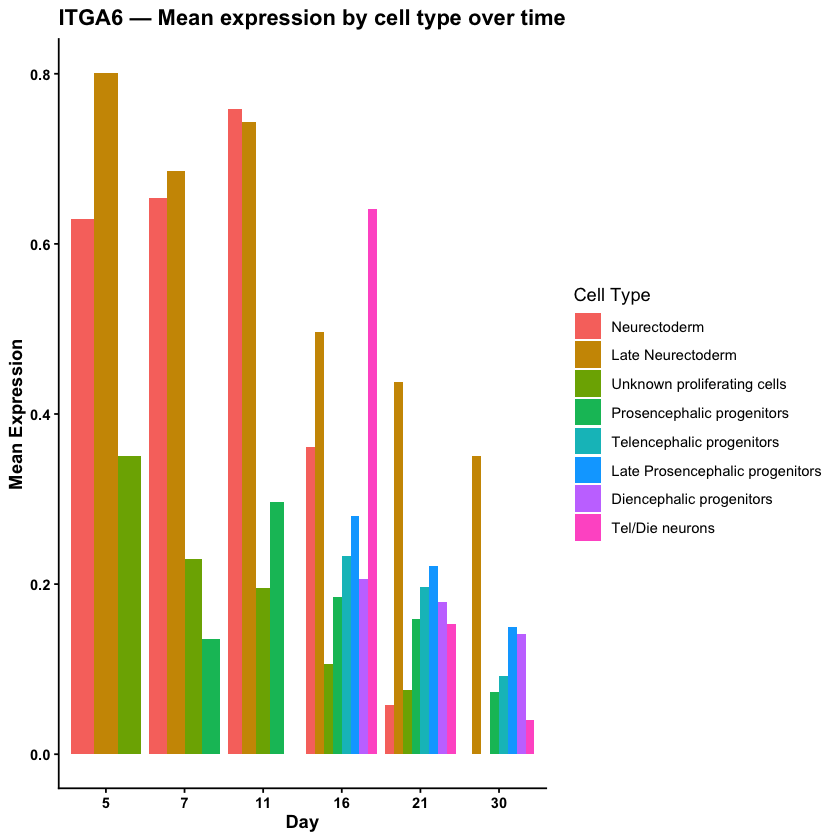

In [66]:
expr_sum <- meta %>%
  group_by(day, class3) %>%
  summarise(mean_expr = mean(expr), .groups = "drop")

ggplot(expr_sum, aes(x = factor(day), y = mean_expr, fill = class3)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = paste(gene, "— Mean expression by cell type over time"),
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold")
  )



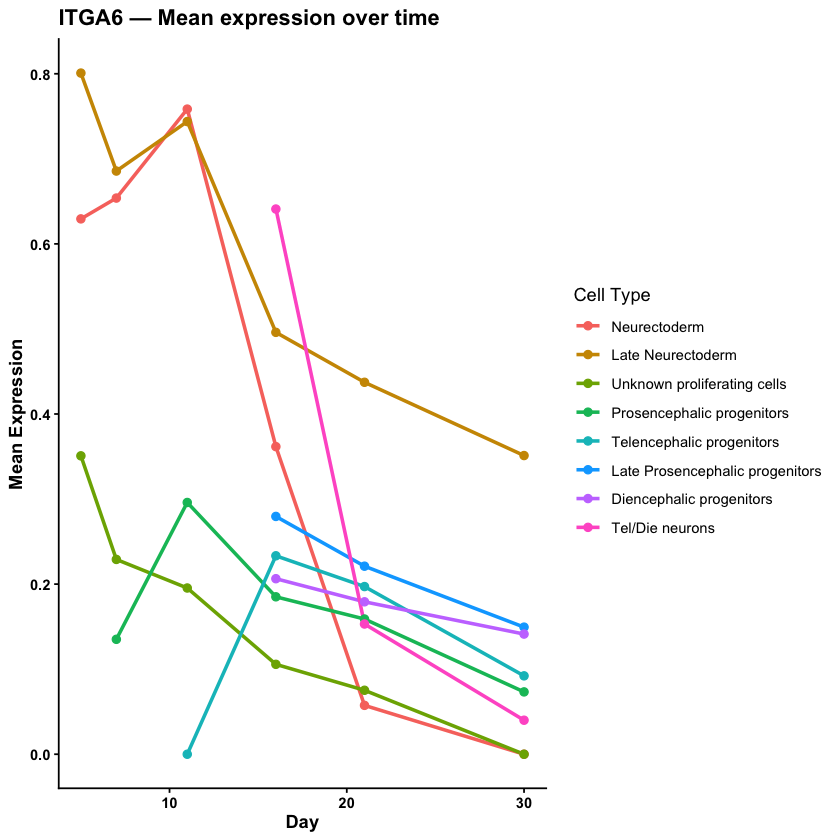

In [67]:
# Alternate to the doge plot

expr_mean <- meta %>%
  group_by(day, class3) %>%
  summarise(mean_expr = mean(expr), .groups = "drop")

ggplot(expr_mean, aes(x = day, y = mean_expr, color = class3)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(title = paste(gene, "— Mean expression over time"),
       x = "Day", y = "Mean Expression", color = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold")
  )



### Weighted stacked plot (total expression withing cell and class group but weighted by total cells per day)

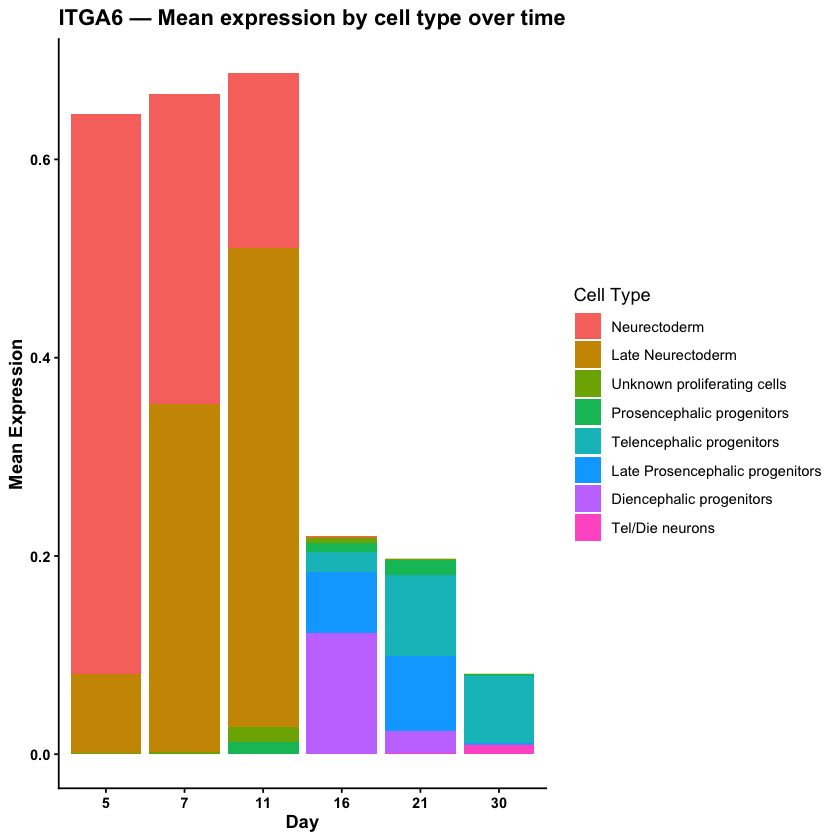

In [68]:
expr_sum <- meta %>%
  group_by(day, class3) %>%
  summarise(total_expr = sum(expr), n = n(), .groups = "drop") %>%
  group_by(day) %>%
  mutate(day_total_cells = sum(n),
         weighted_mean = total_expr / day_total_cells)

ggplot(expr_sum, aes(x = factor(day), y = weighted_mean, fill = class3)) +
  geom_bar(stat = "identity") +
  labs(title = paste(gene, "— Mean expression by cell type over time"),
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold")
  )


### Normalized stacked plot

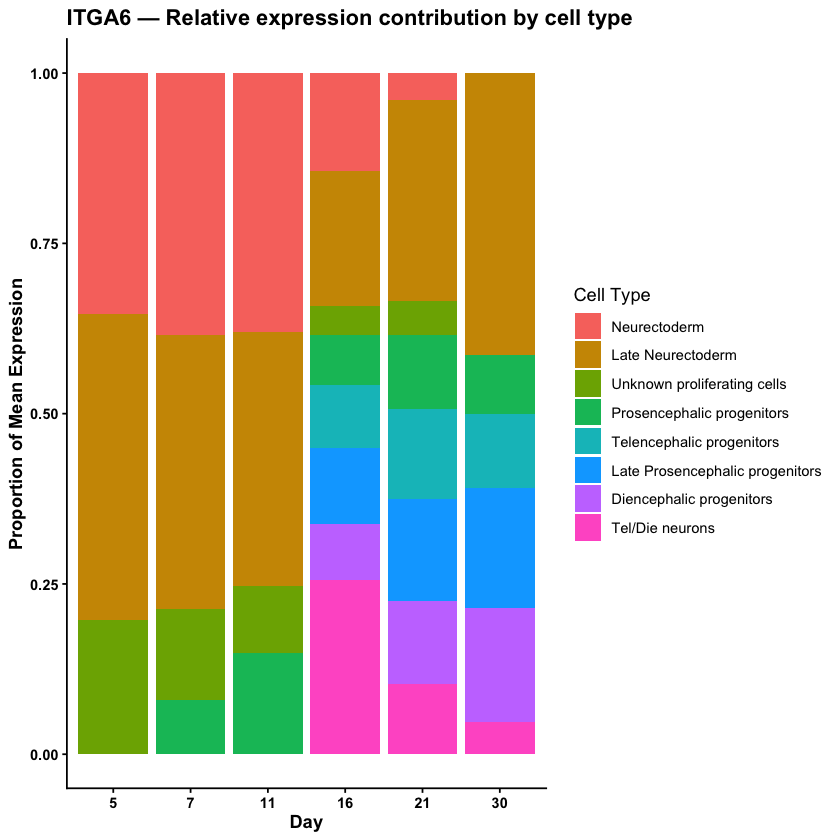

In [69]:
expr_mean <- meta %>%
  group_by(day, class3) %>%
  summarise(mean_expr = mean(expr), .groups = "drop") %>%
  group_by(day) %>%
  mutate(proportion = mean_expr / sum(mean_expr))

ggplot(expr_mean, aes(x = factor(day), y = proportion, fill = class3)) +
  geom_bar(stat = "identity") +
  labs(title = paste(gene, "— Relative expression contribution by cell type"),
       x = "Day", y = "Proportion of Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold")
  )


### Weighted stacked plot but witht he normalized cell type proportions

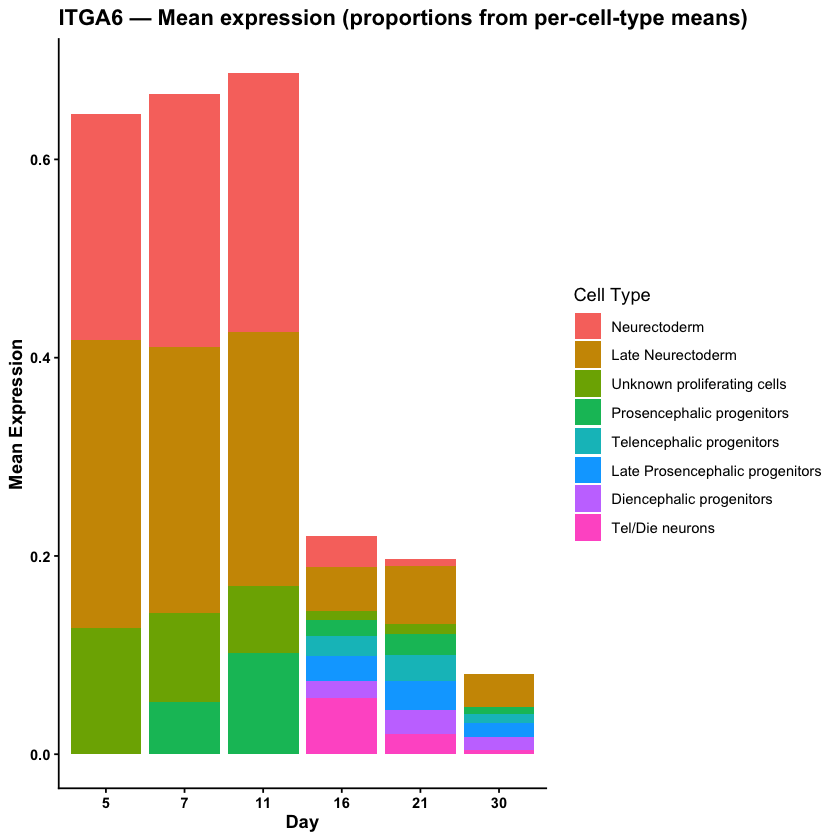

In [70]:
# Get overall mean per day (bar heights)
overall_mean <- meta %>%
  group_by(day) %>%
  summarise(day_mean = mean(expr), .groups = "drop")

# Get cell-number-independent proportions
expr_mean <- meta %>%
  group_by(day, class3) %>%
  summarise(mean_expr = mean(expr), .groups = "drop") %>%
  group_by(day) %>%
  mutate(proportion = mean_expr / sum(mean_expr))

# Combine: scale proportions by overall mean
combined <- expr_mean %>%
  left_join(overall_mean, by = "day") %>%
  mutate(segment_height = proportion * day_mean)

ggplot(combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  labs(title = paste(gene, "— Mean expression (proportions from per-cell-type means)"),
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold")
  )



Warning message:
“Removed 76 rows containing missing values or values outside the scale range
(`geom_bar()`).”


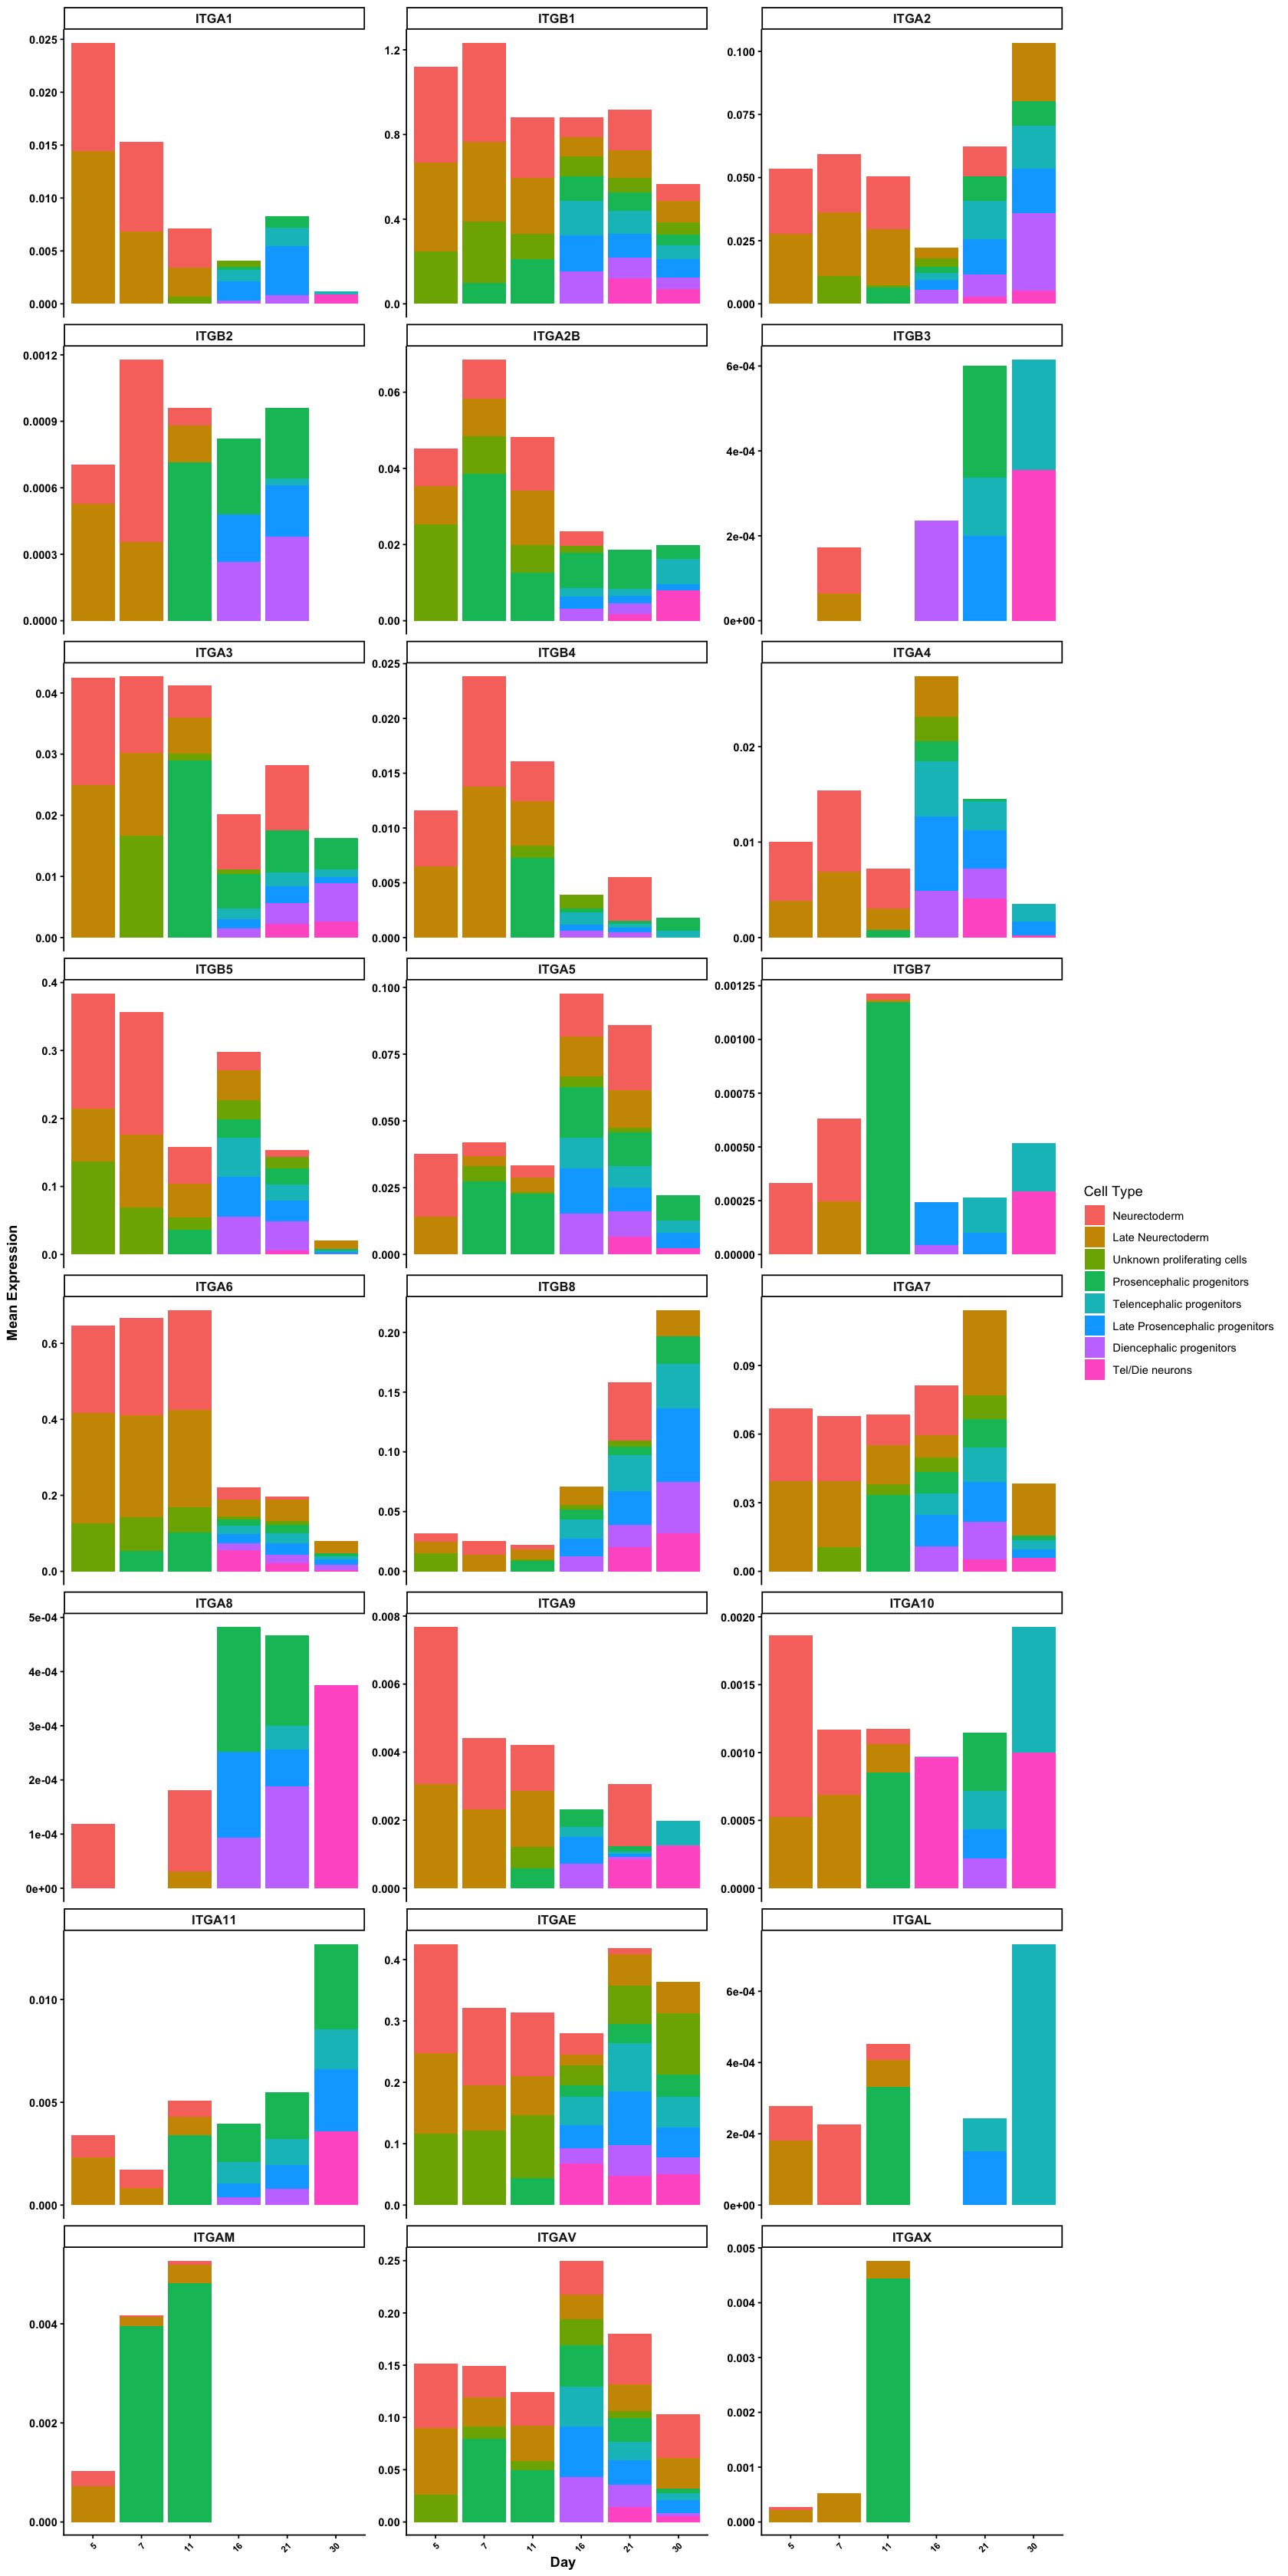

In [85]:
all_combined <- data.frame()

for (gene in integrin_genes) {
  expr <- GetAssayData(timecourse, layer = "data")[gene, ]
  meta <- timecourse@meta.data
  meta$expr <- expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           gene = gene)
  
  all_combined <- rbind(all_combined, combined)
}

# Order: alpha and beta pairs side by side
gene_order <- c("ITGA1", "ITGB1", "ITGA2", "ITGB2", "ITGA2B", "ITGB3", 
                "ITGA3", "ITGB4", "ITGA4", "ITGB5", "ITGA5", "ITGB7", 
                "ITGA6", "ITGB8", "ITGA7", "ITGA8", "ITGA9", "ITGA10", 
                "ITGA11", "ITGAD", "ITGAE", "ITGAL", "ITGAM", "ITGAV", "ITGAX")

# Keep only genes that exist in the data
gene_order <- gene_order[gene_order %in% unique(all_combined$gene)]

all_combined$gene <- factor(all_combined$gene, levels = gene_order)

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, scales = "free_y", ncol = 3) +
  labs(x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


Warning message:
“Removed 76 rows containing missing values or values outside the scale range
(`geom_bar()`).”


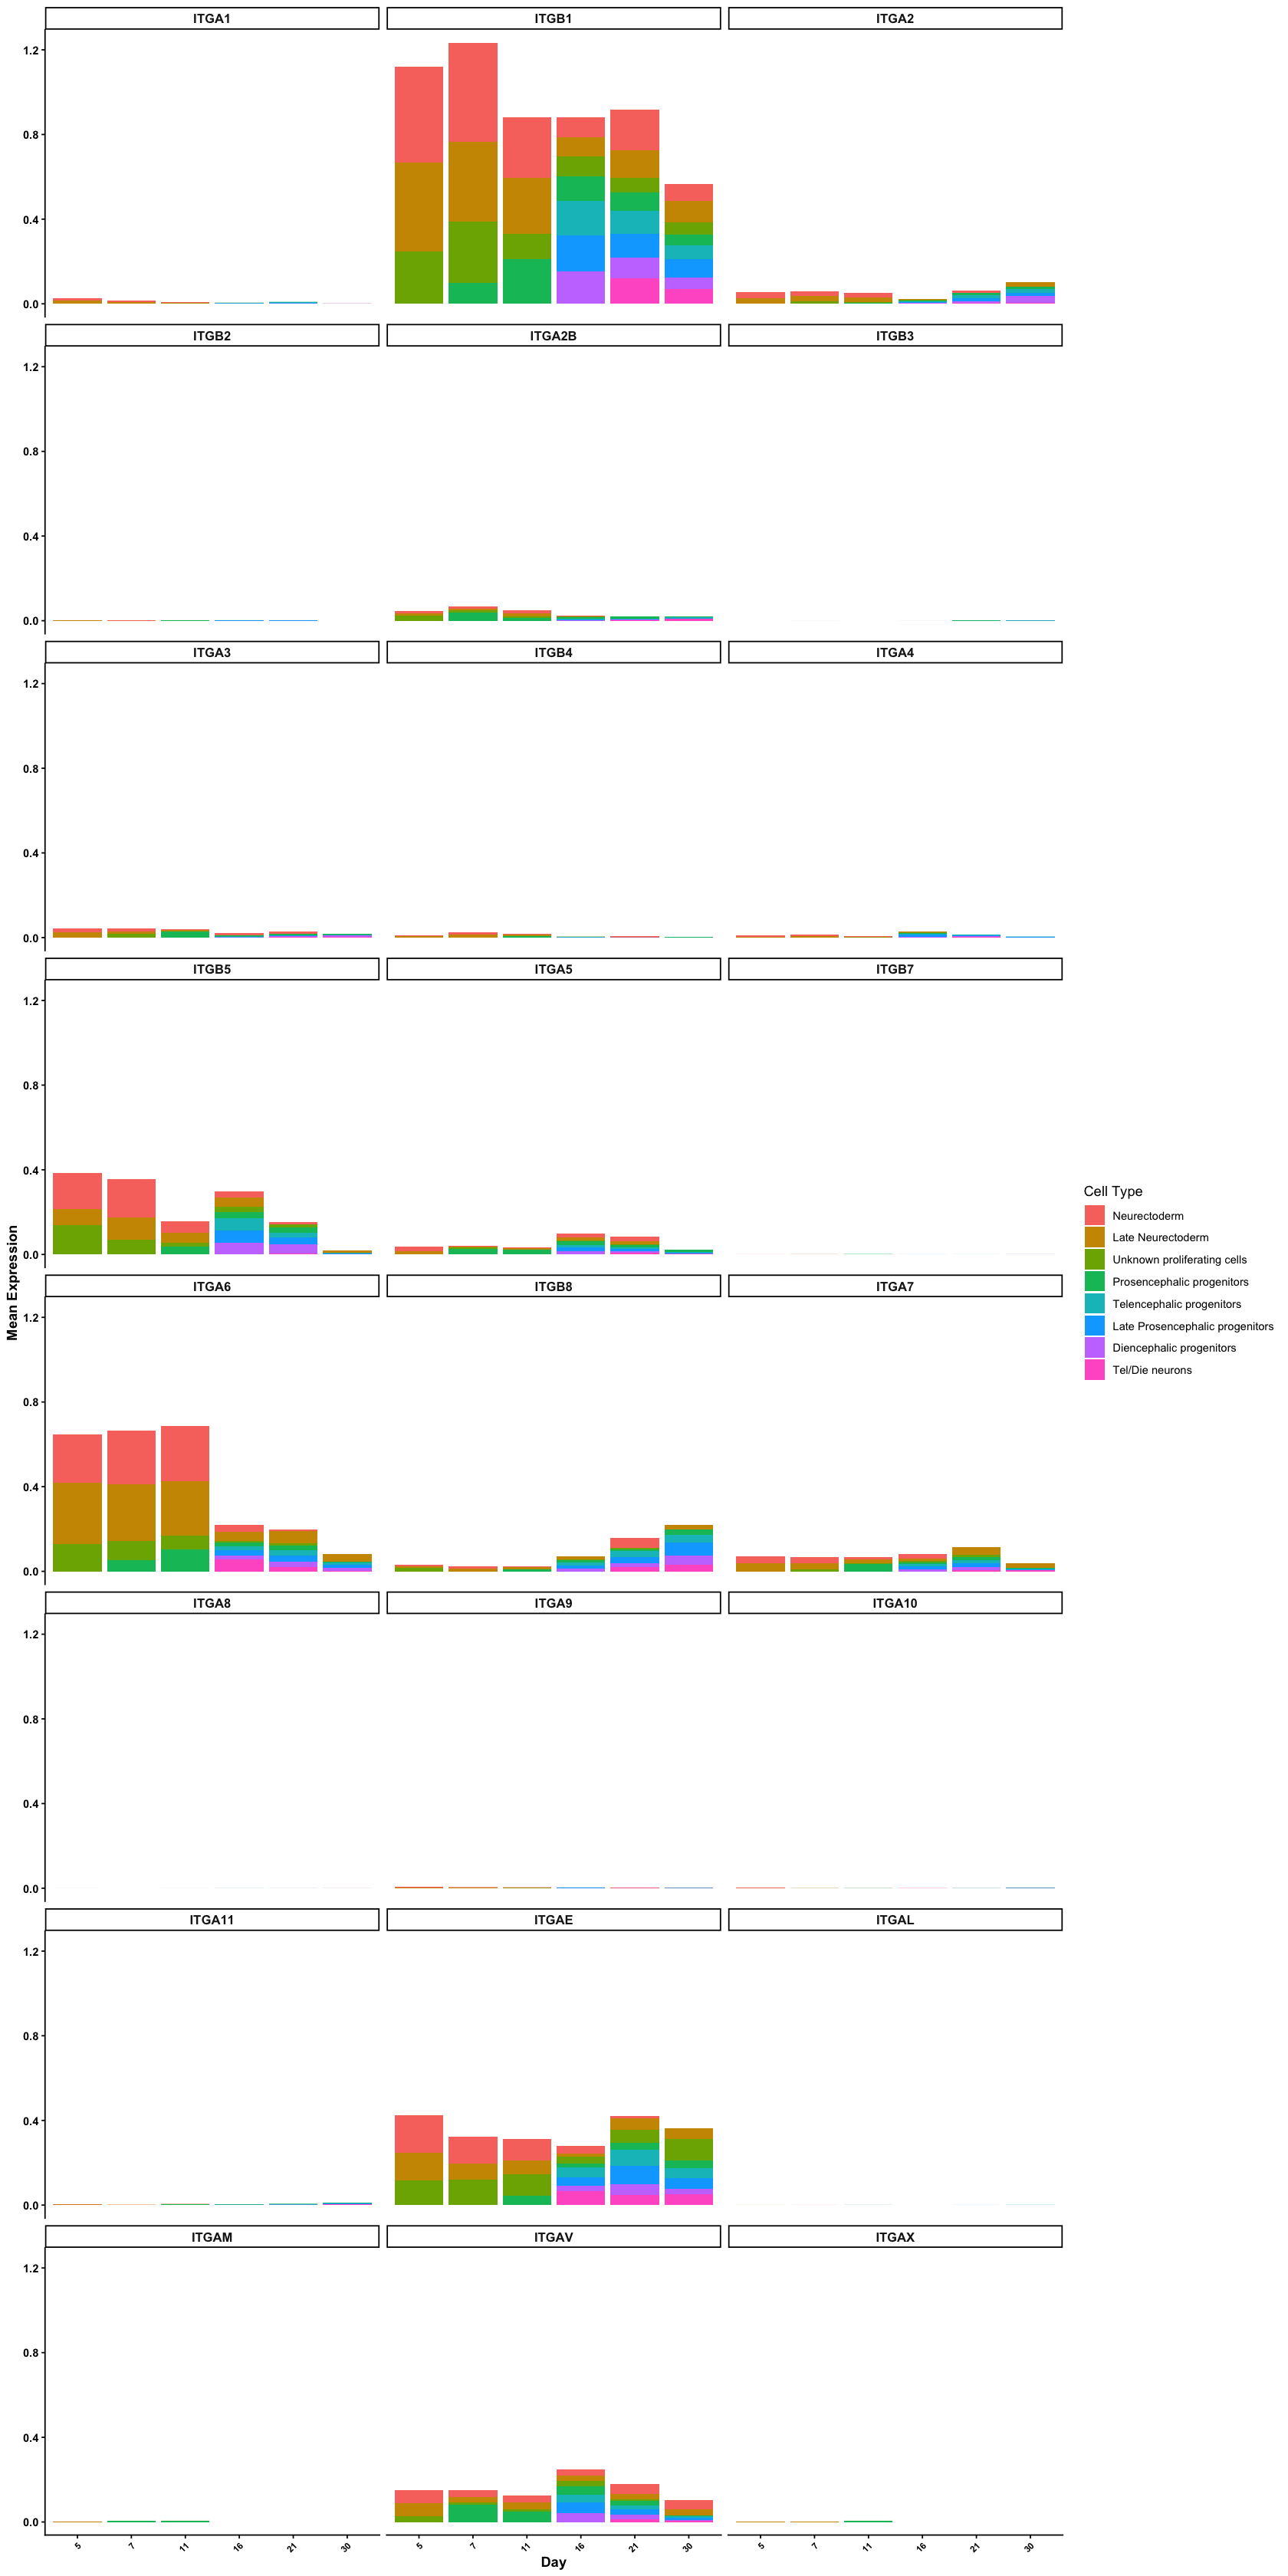

In [86]:
ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, ncol = 3) +
  labs(x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


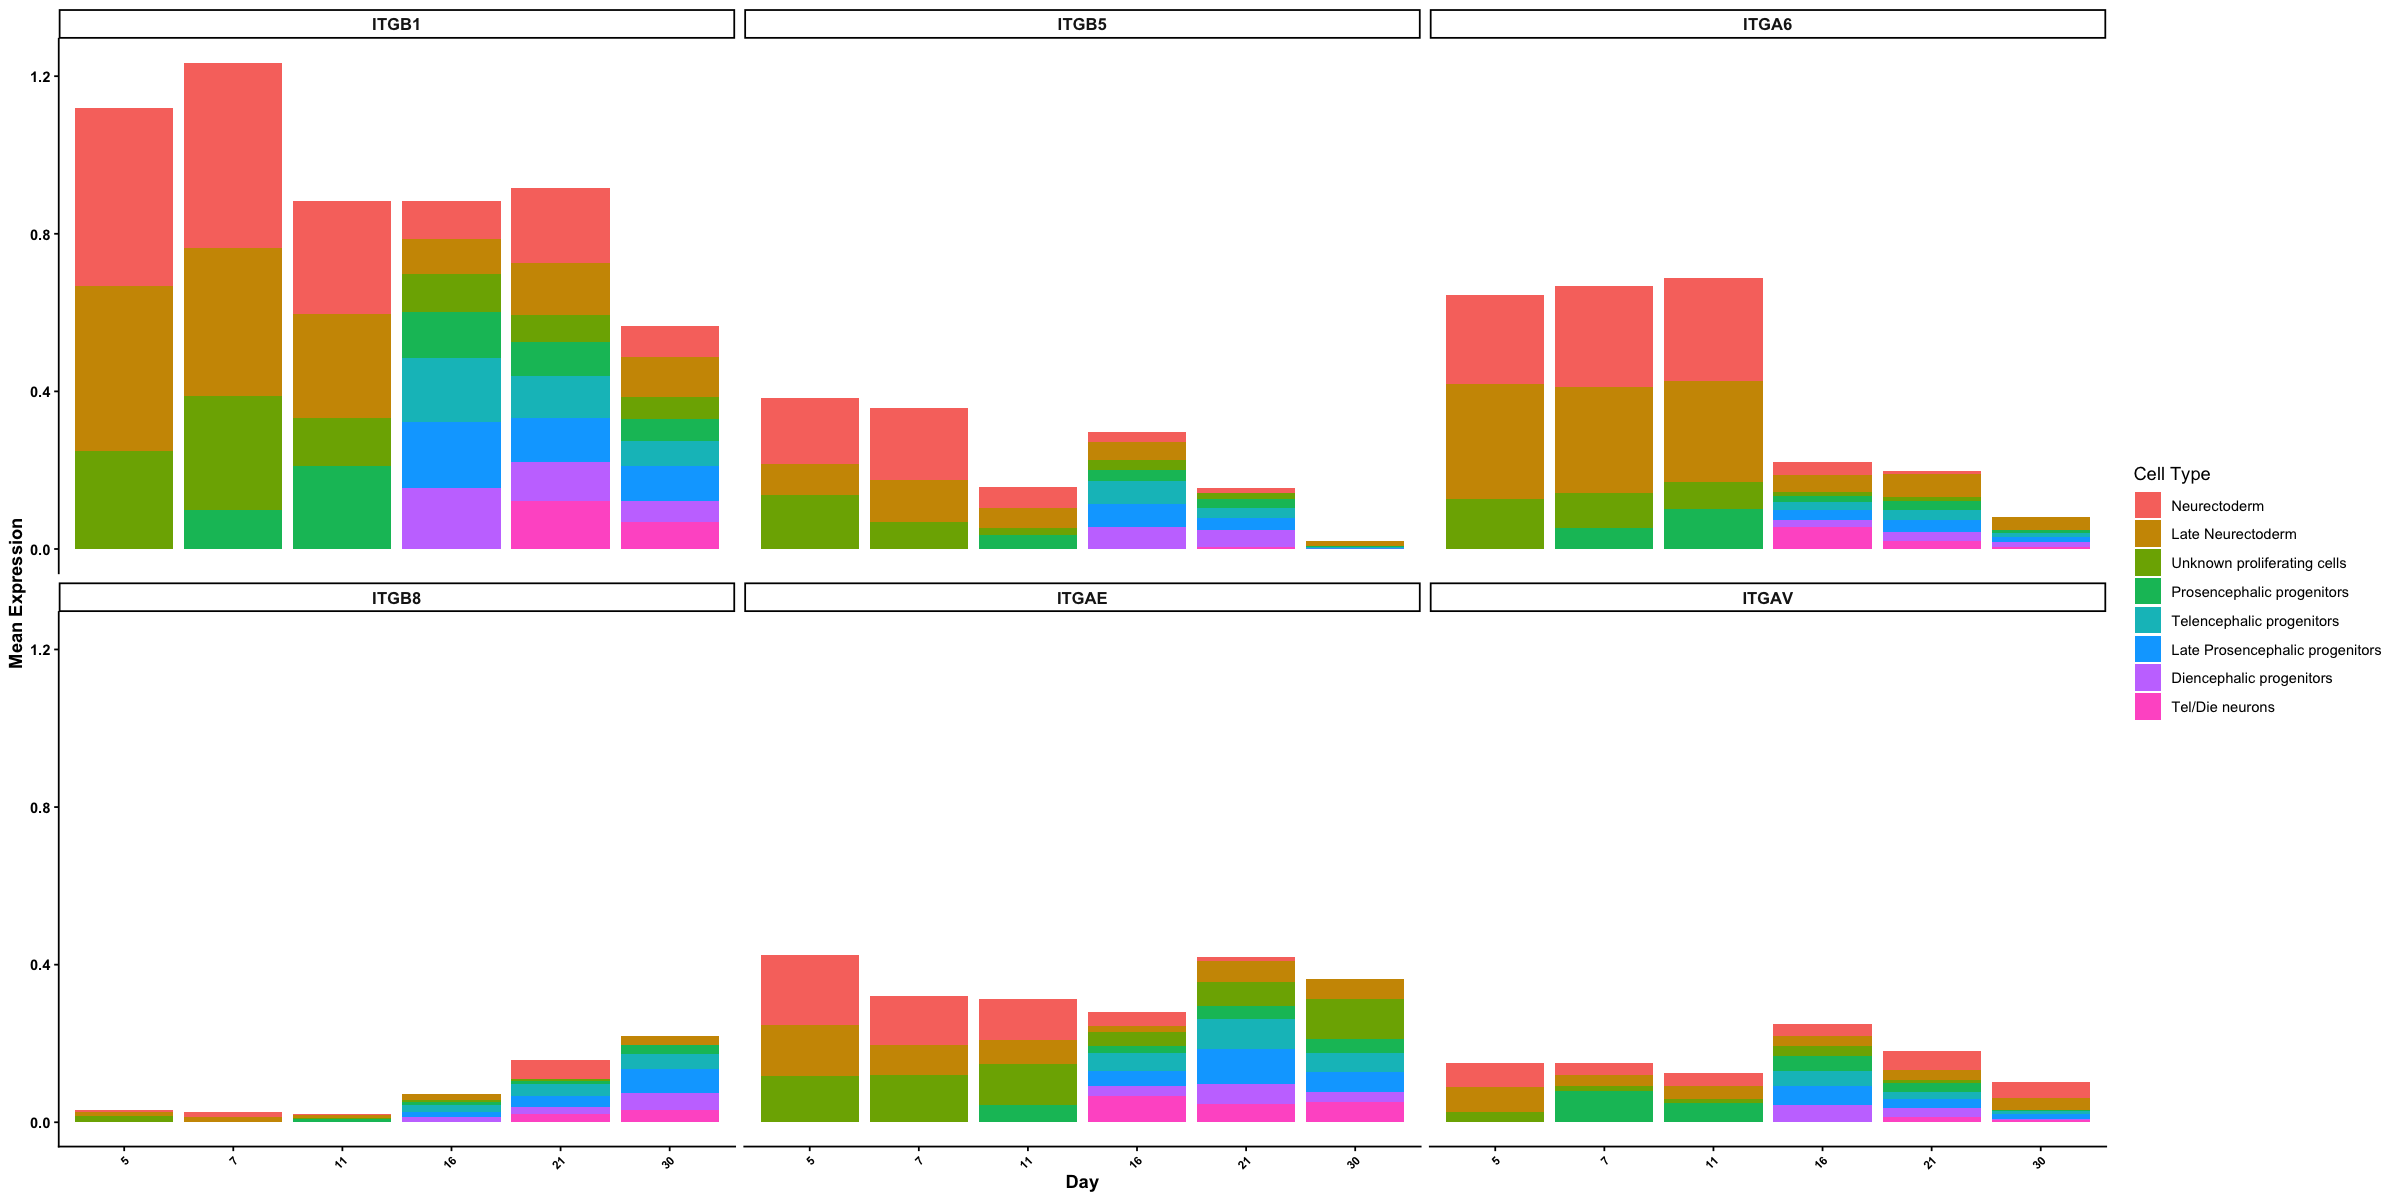

In [126]:
# Keep only genes where max day_mean > 0.2


all_combined <- data.frame()

for (gene in integrin_genes) {
  expr <- GetAssayData(timecourse, layer = "data")[gene, ]
  meta <- timecourse@meta.data
  meta$expr <- expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           gene = gene)
  
  all_combined <- rbind(all_combined, combined)
}

# Keep only genes where max day_mean > 0.2
high_expr_genes <- all_combined %>%
  group_by(gene) %>%
  summarise(max_mean = max(day_mean, na.rm = TRUE)) %>%
  filter(max_mean > 0.2) %>%
  pull(gene)

all_combined <- all_combined %>% filter(gene %in% high_expr_genes)

# Order: alpha and beta pairs side by side
gene_order <- c("ITGA1", "ITGB1", "ITGA2", "ITGB2", "ITGA2B", "ITGB3", 
                "ITGA3", "ITGB4", "ITGA4", "ITGB5", "ITGA5", "ITGB7", 
                "ITGA6", "ITGB8", "ITGA7", "ITGA8", "ITGA9", "ITGA10", 
                "ITGA11", "ITGAD", "ITGAE", "ITGAL", "ITGAM", "ITGAV", "ITGAX")

# Keep only genes that exist in the data
gene_order <- gene_order[gene_order %in% unique(all_combined$gene)]

all_combined$gene <- factor(all_combined$gene, levels = gene_order)

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, ncol = 3) +
  labs(x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


In [ ]:
# Just wanted to check what the marker genes are

Idents(timecourse) <- "class3"

all_markers <- FindAllMarkers(timecourse, 
                              features = integrin_genes,
                              only.pos = TRUE, 
                              min.pct = 0.1, 
                              logfc.threshold = 0.1)

all_markers %>% 
  arrange(cluster, p_val_adj) %>%
  select(cluster, gene, avg_log2FC, pct.1, pct.2, p_val_adj)


Calculating cluster Neurectoderm

Calculating cluster Late Neurectoderm

Calculating cluster Unknown proliferating cells

Calculating cluster Prosencephalic progenitors

Calculating cluster Telencephalic progenitors

Calculating cluster Late Prosencephalic progenitors

Calculating cluster Diencephalic progenitors

Calculating cluster Tel/Die neurons



,cluster,gene,avg_log2FC,pct.1,pct.2,p_val_adj
,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ITGA6,Neurectoderm,ITGA6,0.9798121,0.836,0.341,0.000000e+00
ITGB5,Neurectoderm,ITGB5,1.1395931,0.643,0.220,0.000000e+00
ITGB1,Neurectoderm,ITGB1,0.5626573,0.981,0.713,0.000000e+00
ITGA2B,Neurectoderm,ITGA2B,0.5680519,0.132,0.045,1.774940e-181
ITGA3,Neurectoderm,ITGA3,0.2323979,0.100,0.041,1.565637e-96
ITGA61,Late Neurectoderm,ITGA6,1.3674849,0.747,0.393,0.000000e+00
ITGB11,Late Neurectoderm,ITGB1,0.1598262,0.876,0.755,6.685861e-26
ITGA5,Prosencephalic progenitors,ITGA5,1.2584172,0.176,0.083,5.491031e-33
ITGA31,Prosencephalic progenitors,ITGA3,1.6112963,0.114,0.053,6.141834e-21


### Grouping integrins by ligand class

In [94]:
library(tidyr)

ligand_table <- data.frame(
  Collagen = c("ITGA1", "ITGA2", "ITGA10", "ITGA11", "ITGB1", "", ""),
  Laminin = c("ITGA3", "ITGA6", "ITGA7", "ITGB1", "ITGB4", "", ""),
  RGD = c("ITGAV", "ITGA5", "ITGA8", "ITGB1", "ITGB3", "ITGB5", "ITGB8"),
  Leukocyte = c("ITGAL", "ITGAM", "ITGAX", "ITGAE", "ITGA4", "ITGB2", "ITGB7"),
  Other = c("ITGA9", "ITGA2B", "", "", "", "", "")
)

ligand_table


Collagen,Laminin,RGD,Leukocyte,Other
<chr>,<chr>,<chr>,<chr>,<chr>
ITGA1,ITGA3,ITGAV,ITGAL,ITGA9
ITGA2,ITGA6,ITGA5,ITGAM,ITGA2B
ITGA10,ITGA7,ITGA8,ITGAX,
ITGA11,ITGB1,ITGB1,ITGAE,
ITGB1,ITGB4,ITGB3,ITGA4,
,,ITGB5,ITGB2,
,,ITGB8,ITGB7,


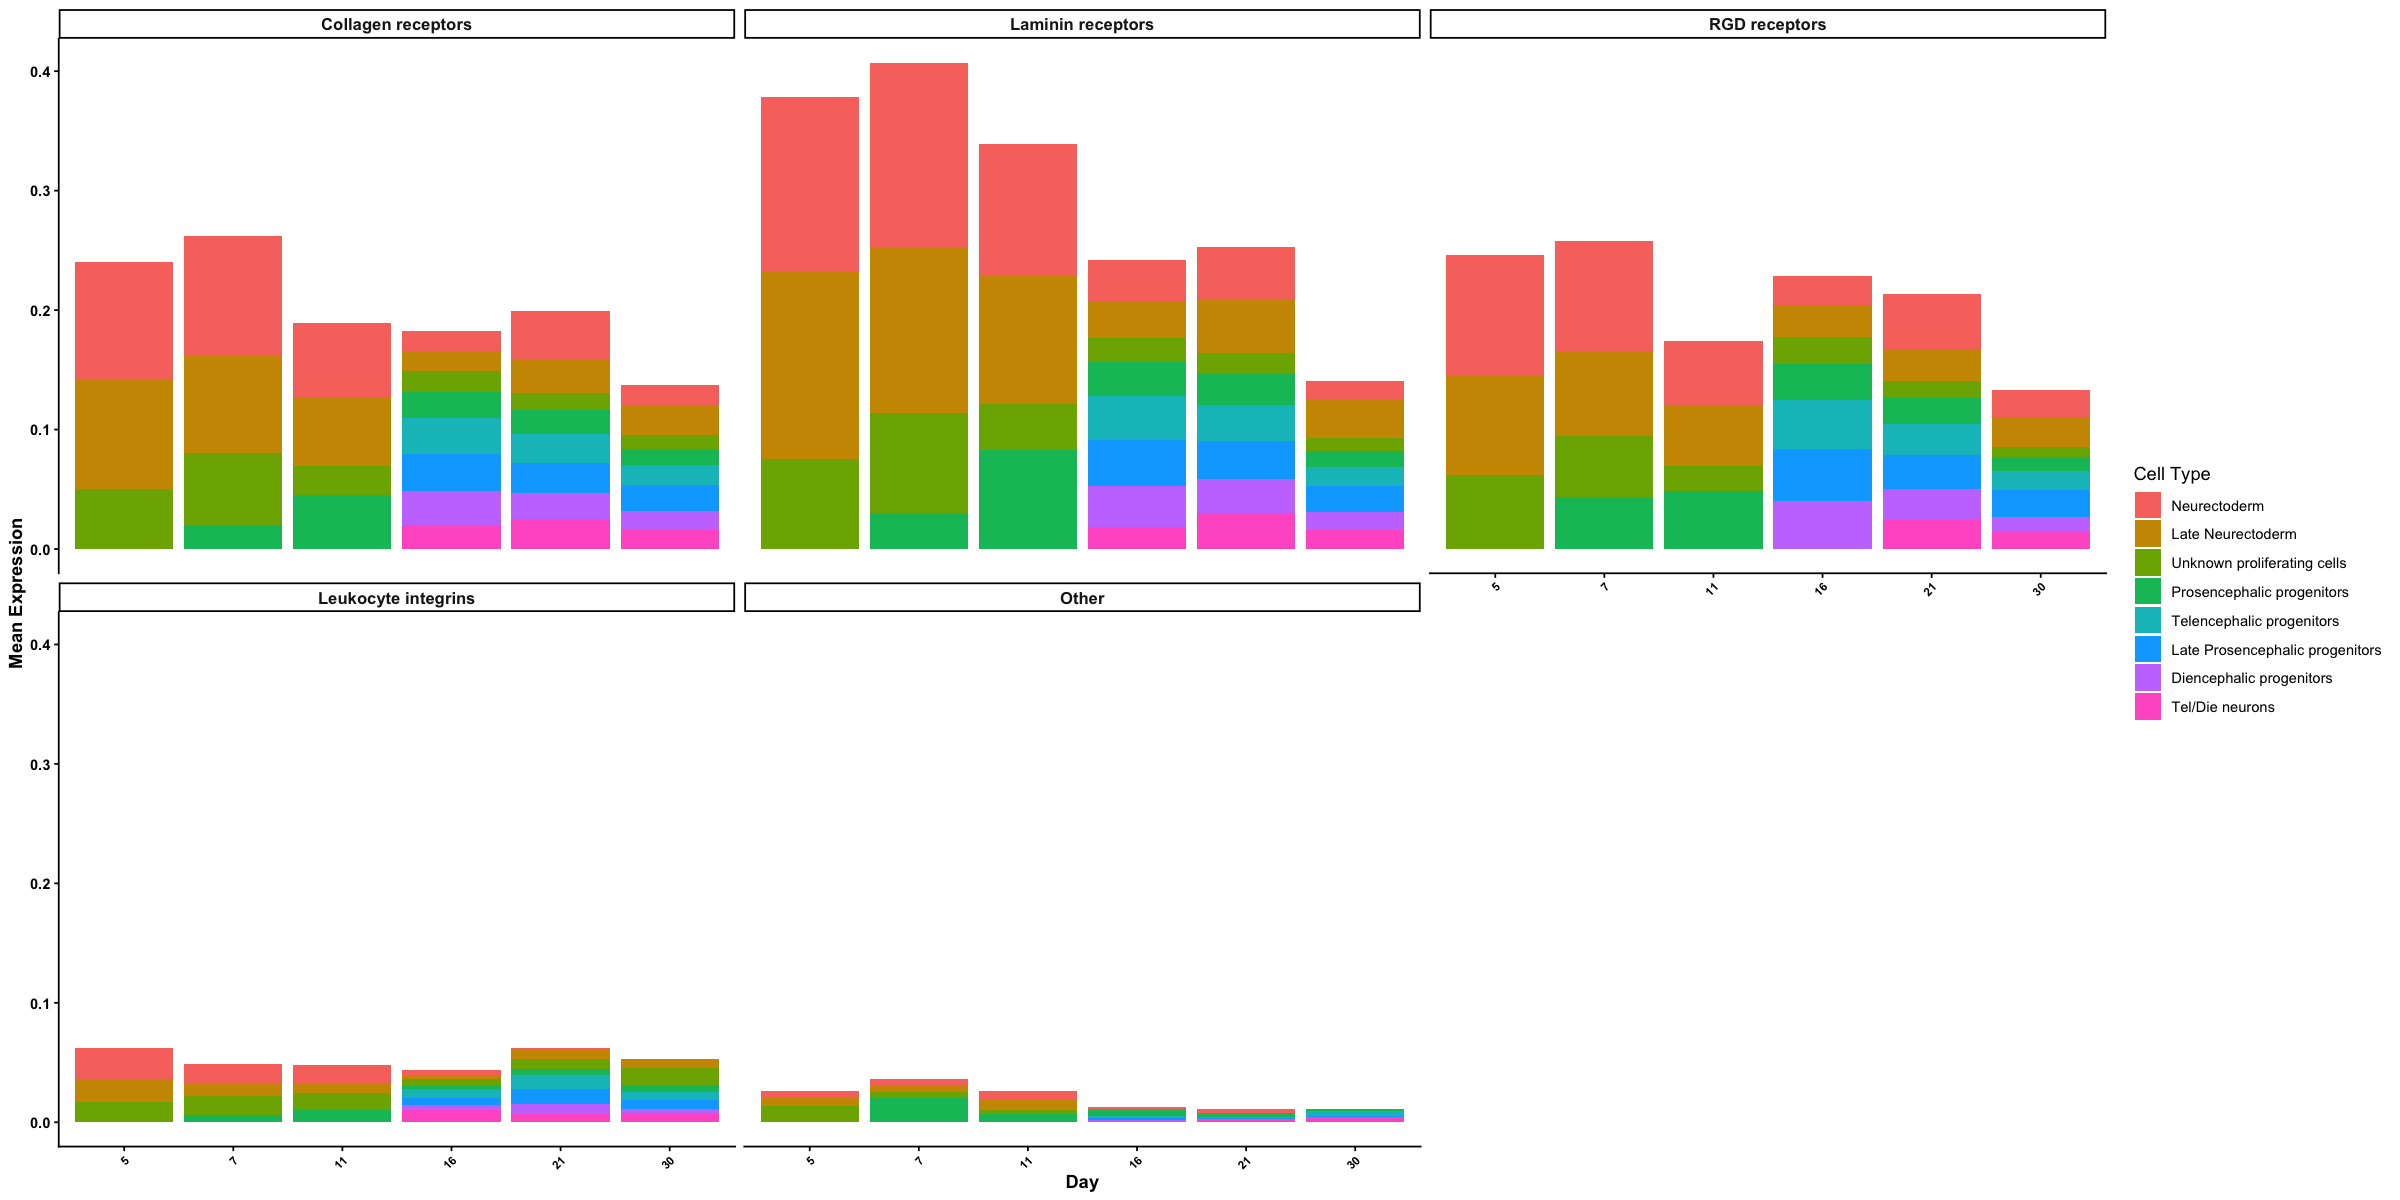

In [125]:
# Define integrin ligand classes
ligand_classes <- list(
  "Collagen receptors" = c("ITGA1", "ITGA2", "ITGA10", "ITGA11", "ITGB1"),
  "Laminin receptors" = c("ITGA3", "ITGA6", "ITGA7", "ITGB1", "ITGB4"),
  "RGD receptors" = c("ITGAV", "ITGA5", "ITGA8", "ITGB1", "ITGB3", "ITGB5", "ITGB8"),
  "Leukocyte integrins" = c("ITGAL", "ITGAM", "ITGAX", "ITGAE", "ITGA4", "ITGB2", "ITGB7"),
  "Other" = c("ITGA9", "ITGA2B")
)

# Filter to genes actually in the dataset
ligand_classes <- lapply(ligand_classes, function(genes) {
  genes[genes %in% rownames(timecourse)]
})

# Build combined data for all ligand classes
all_combined <- data.frame()

for (lc in names(ligand_classes)) {
  genes <- ligand_classes[[lc]]
  
  # Average expression across all genes in the class per cell
  expr_mat <- GetAssayData(timecourse, layer = "data")[genes, , drop = FALSE]
  avg_expr <- colMeans(expr_mat)
  
  meta <- timecourse@meta.data
  meta$expr <- avg_expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           ligand_class = lc)
  
  all_combined <- rbind(all_combined, combined)
}

all_combined$ligand_class <- factor(all_combined$ligand_class, 
                                    levels = names(ligand_classes))

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ligand_class, ncol = 3) +
  labs(x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


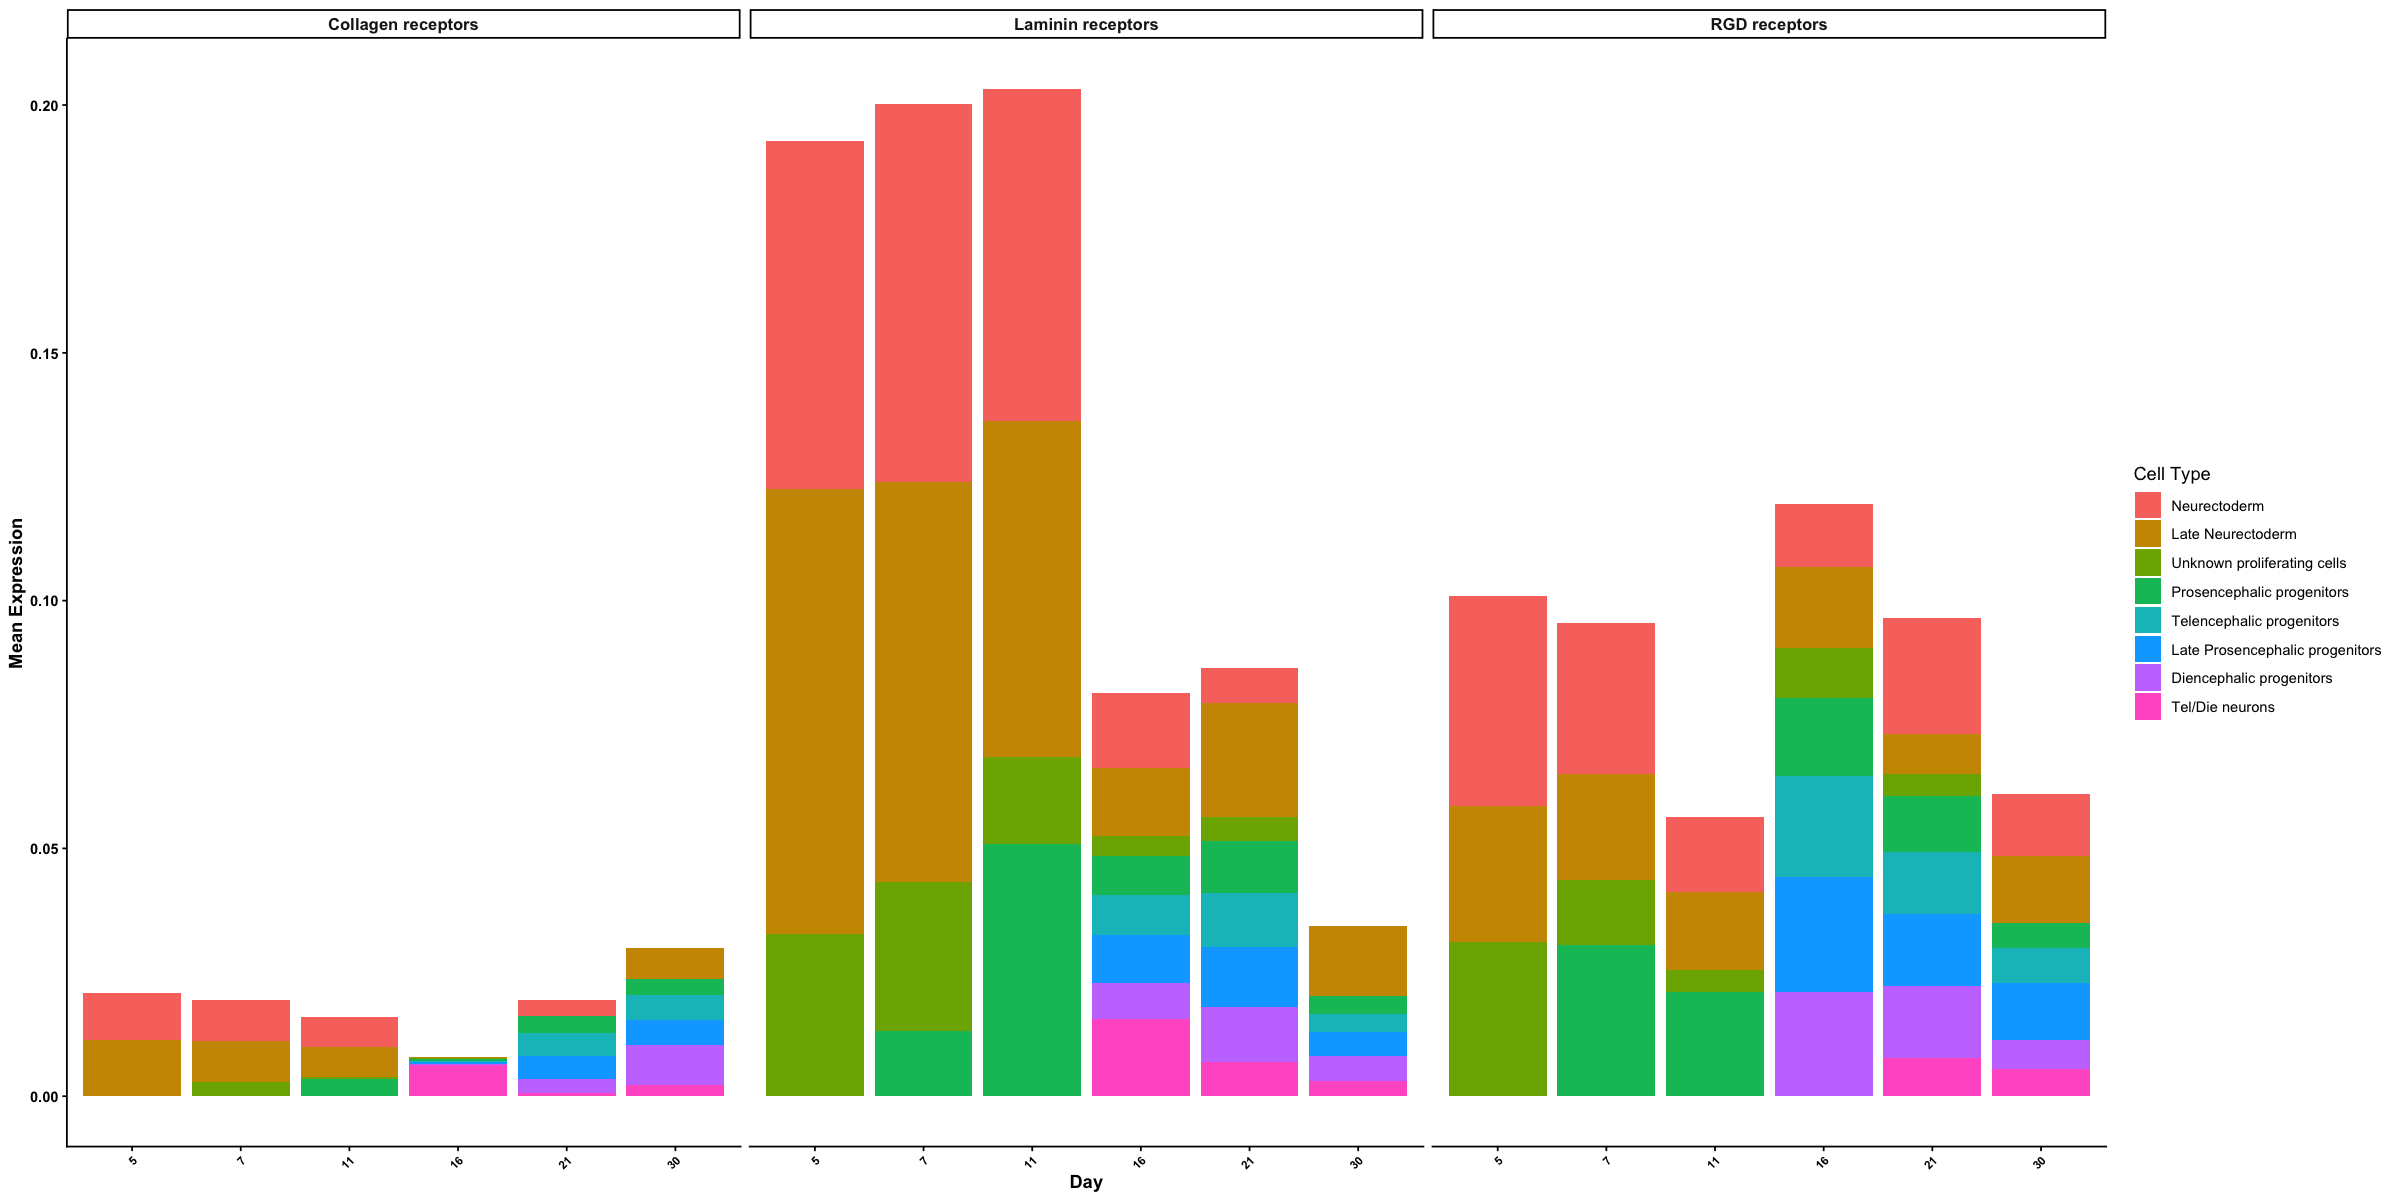

In [127]:
# Define integrin ligand classes
ligand_classes <- list(
  "Collagen receptors" = c("ITGA1", "ITGA2", "ITGA10", "ITGA11"),
  "Laminin receptors" = c("ITGA3", "ITGA6", "ITGA7", "ITGB4"),
  "RGD receptors" = c("ITGAV", "ITGA5", "ITGA8", "ITGB3", "ITGB5", "ITGB8")
)


# Filter to genes actually in the dataset
ligand_classes <- lapply(ligand_classes, function(genes) {
  genes[genes %in% rownames(timecourse)]
})

# Build combined data for all ligand classes
all_combined <- data.frame()

for (lc in names(ligand_classes)) {
  genes <- ligand_classes[[lc]]
  
  # Average expression across all genes in the class per cell
  expr_mat <- GetAssayData(timecourse, layer = "data")[genes, , drop = FALSE]
  avg_expr <- colMeans(expr_mat)
  
  meta <- timecourse@meta.data
  meta$expr <- avg_expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           ligand_class = lc)
  
  all_combined <- rbind(all_combined, combined)
}

all_combined$ligand_class <- factor(all_combined$ligand_class, 
                                    levels = names(ligand_classes))

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ligand_class, ncol = 3) +
  labs(x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


### RGD receptor group

Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_bar()`).”


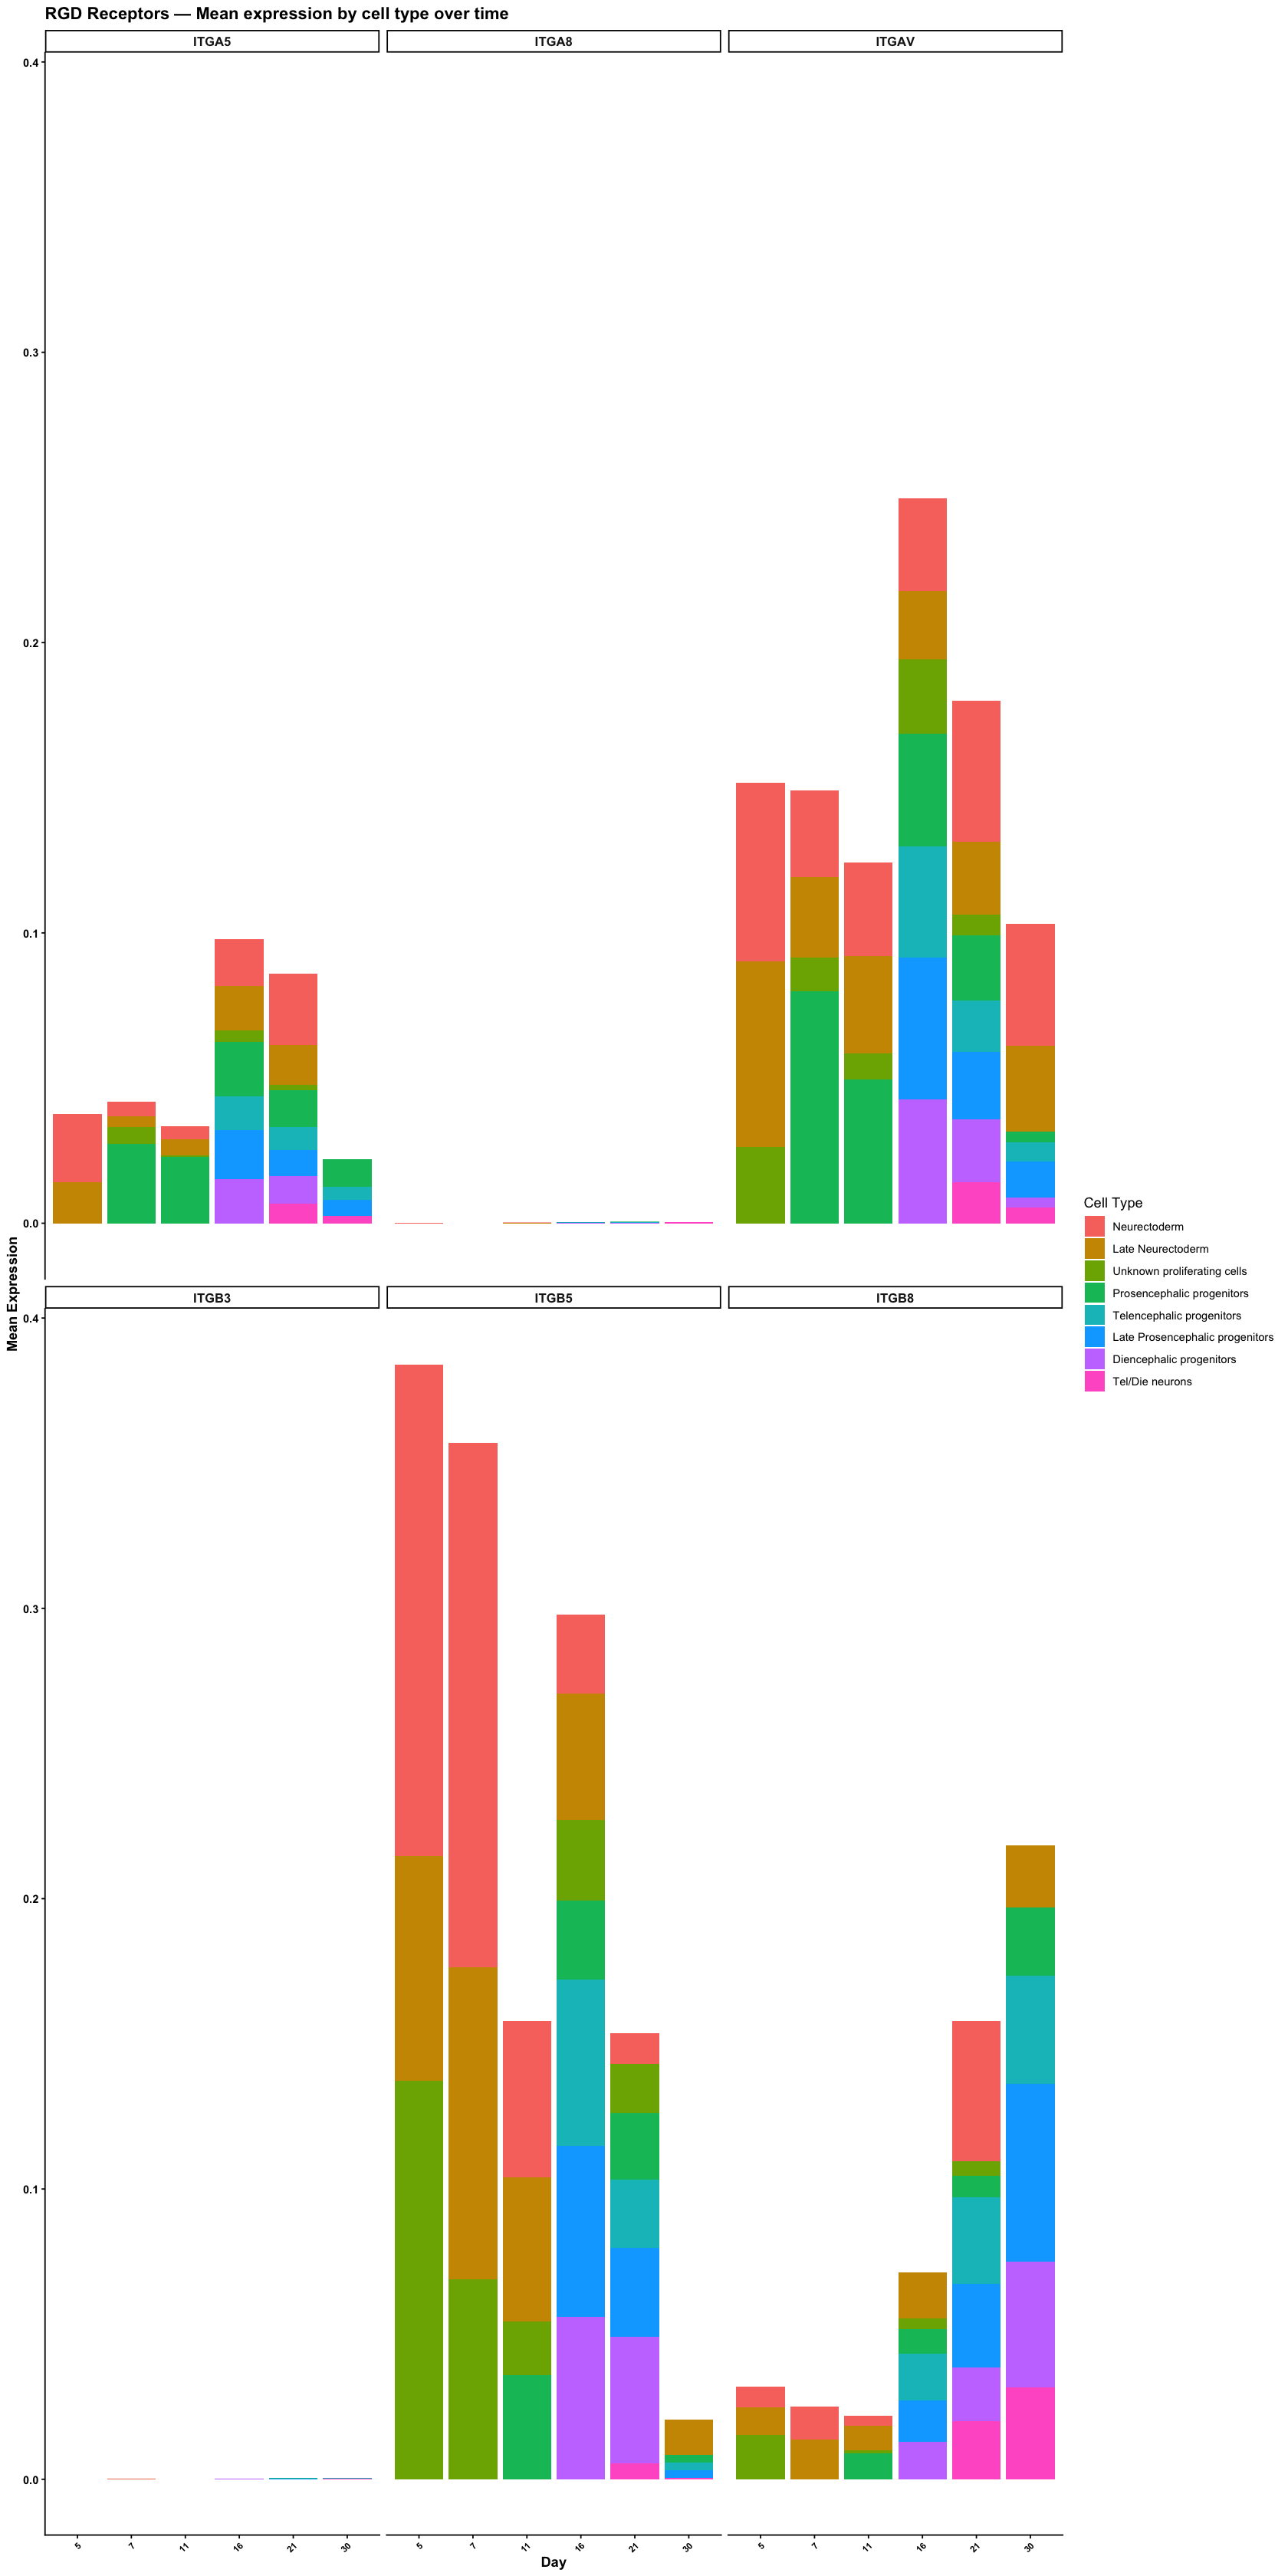

In [ ]:
rgd_genes <- c("ITGAV", "ITGA5", "ITGA8", "ITGB3", "ITGB5", "ITGB8")
rgd_genes <- rgd_genes[rgd_genes %in% rownames(timecourse)]

all_combined <- data.frame()

for (gene in rgd_genes) {
  expr <- GetAssayData(timecourse, layer = "data")[gene, ]
  meta <- timecourse@meta.data
  meta$expr <- expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           gene = gene)
  
  all_combined <- rbind(all_combined, combined)
}

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, scales = "free_y", ncol = 3) +
  labs(title = "RGD Receptors — Mean expression by cell type over time",
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


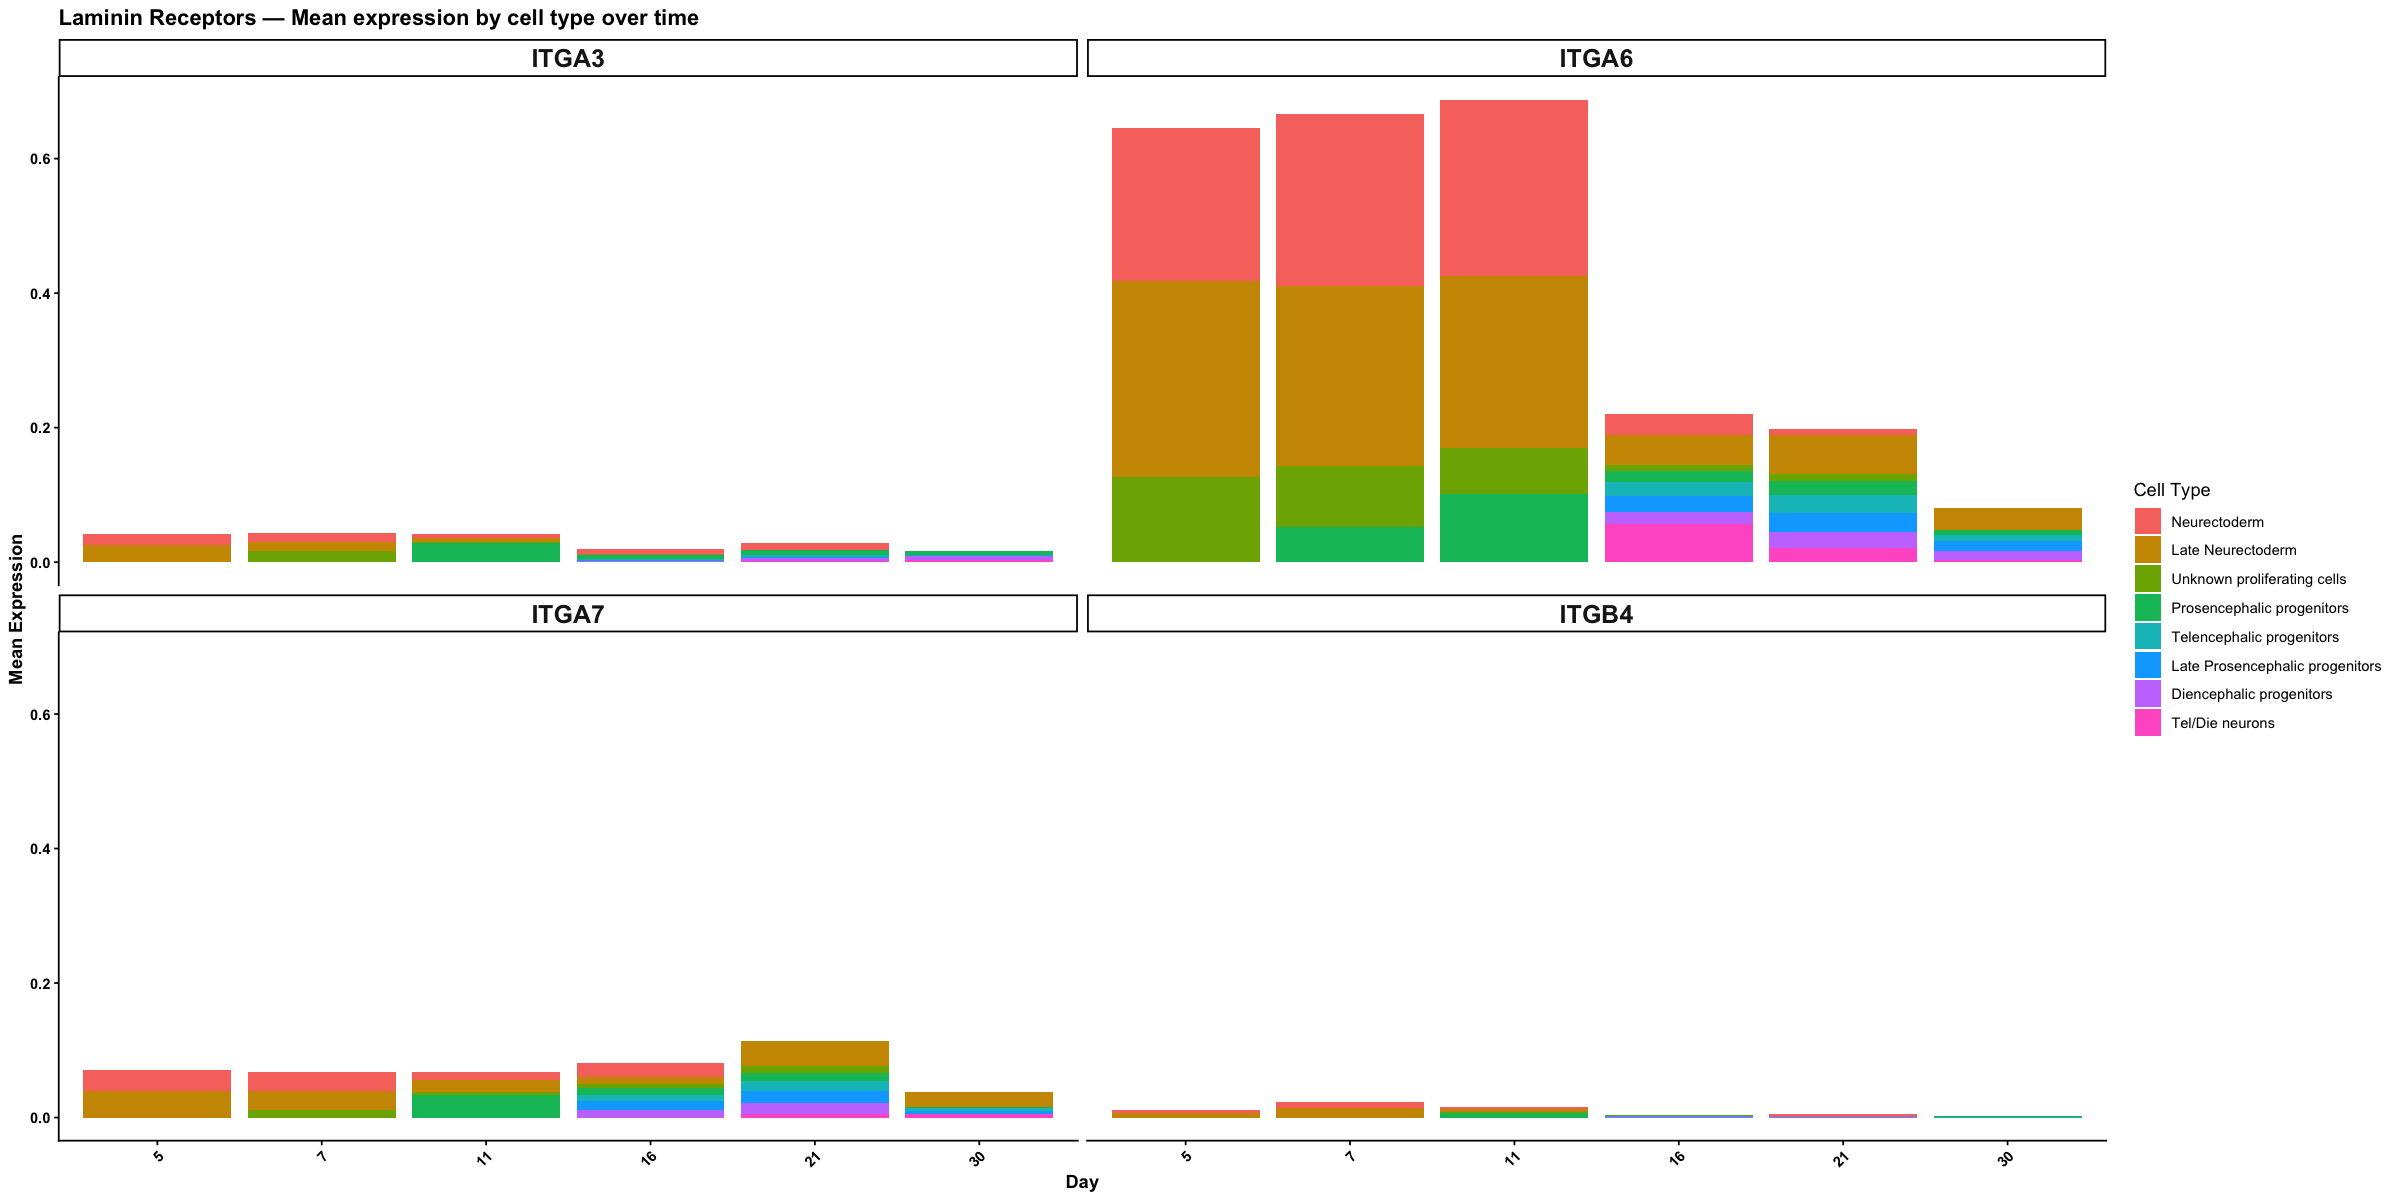

In [ ]:
# Laminin

laminin_genes <- c("ITGA3", "ITGA6", "ITGA7", "ITGB4")
laminin_genes <- laminin_genes[laminin_genes %in% rownames(timecourse)]

all_combined <- data.frame()

for (gene in laminin_genes) {
  expr <- GetAssayData(timecourse, layer = "data")[gene, ]
  meta <- timecourse@meta.data
  meta$expr <- expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           gene = gene)
  
  all_combined <- rbind(all_combined, combined)
}

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, scales = "free_y", ncol = 2) +
  labs(title = "Laminin Receptors — Mean expression by cell type over time",
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold", size = 15),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = )
  )


In [109]:
options(repr.plot.width = 20, repr.plot.height = 10)


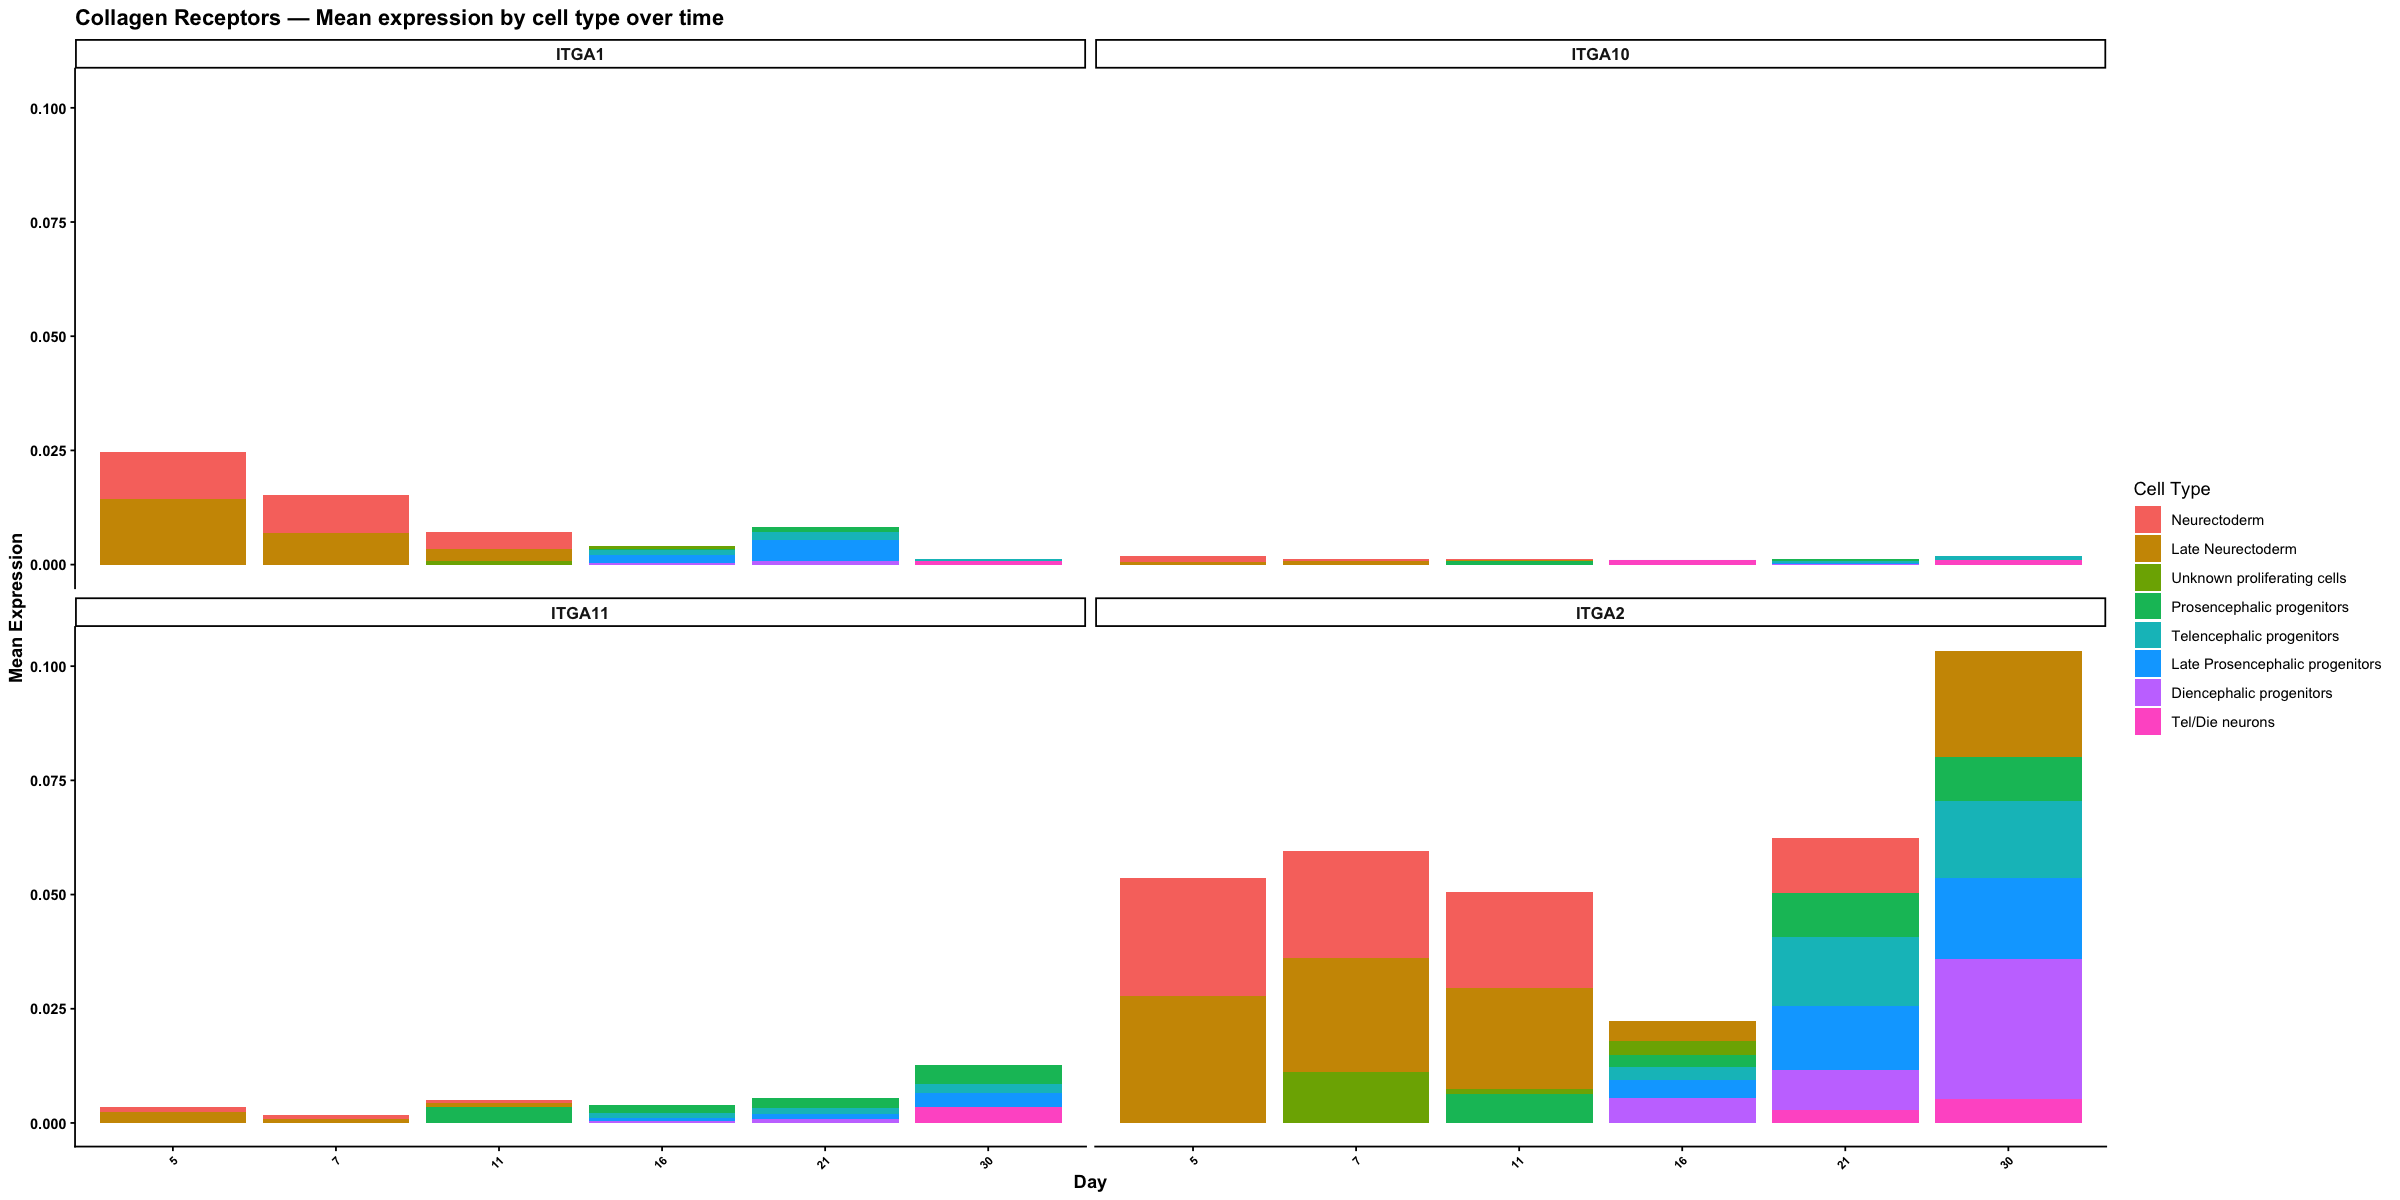

In [ ]:
# Collagen

collagen_genes <- c("ITGA1", "ITGA2", "ITGA10", "ITGA11")
collagen_genes <- collagen_genes[collagen_genes %in% rownames(timecourse)]

all_combined <- data.frame()

for (gene in collagen_genes) {
  expr <- GetAssayData(timecourse, layer = "data")[gene, ]
  meta <- timecourse@meta.data
  meta$expr <- expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           gene = gene)
  
  all_combined <- rbind(all_combined, combined)
}

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, scales = "free_y", ncol = 2) +
  labs(title = "Collagen Receptors — Mean expression by cell type over time",
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


Warning message:
“Removed 64 rows containing missing values or values outside the scale range
(`geom_bar()`).”


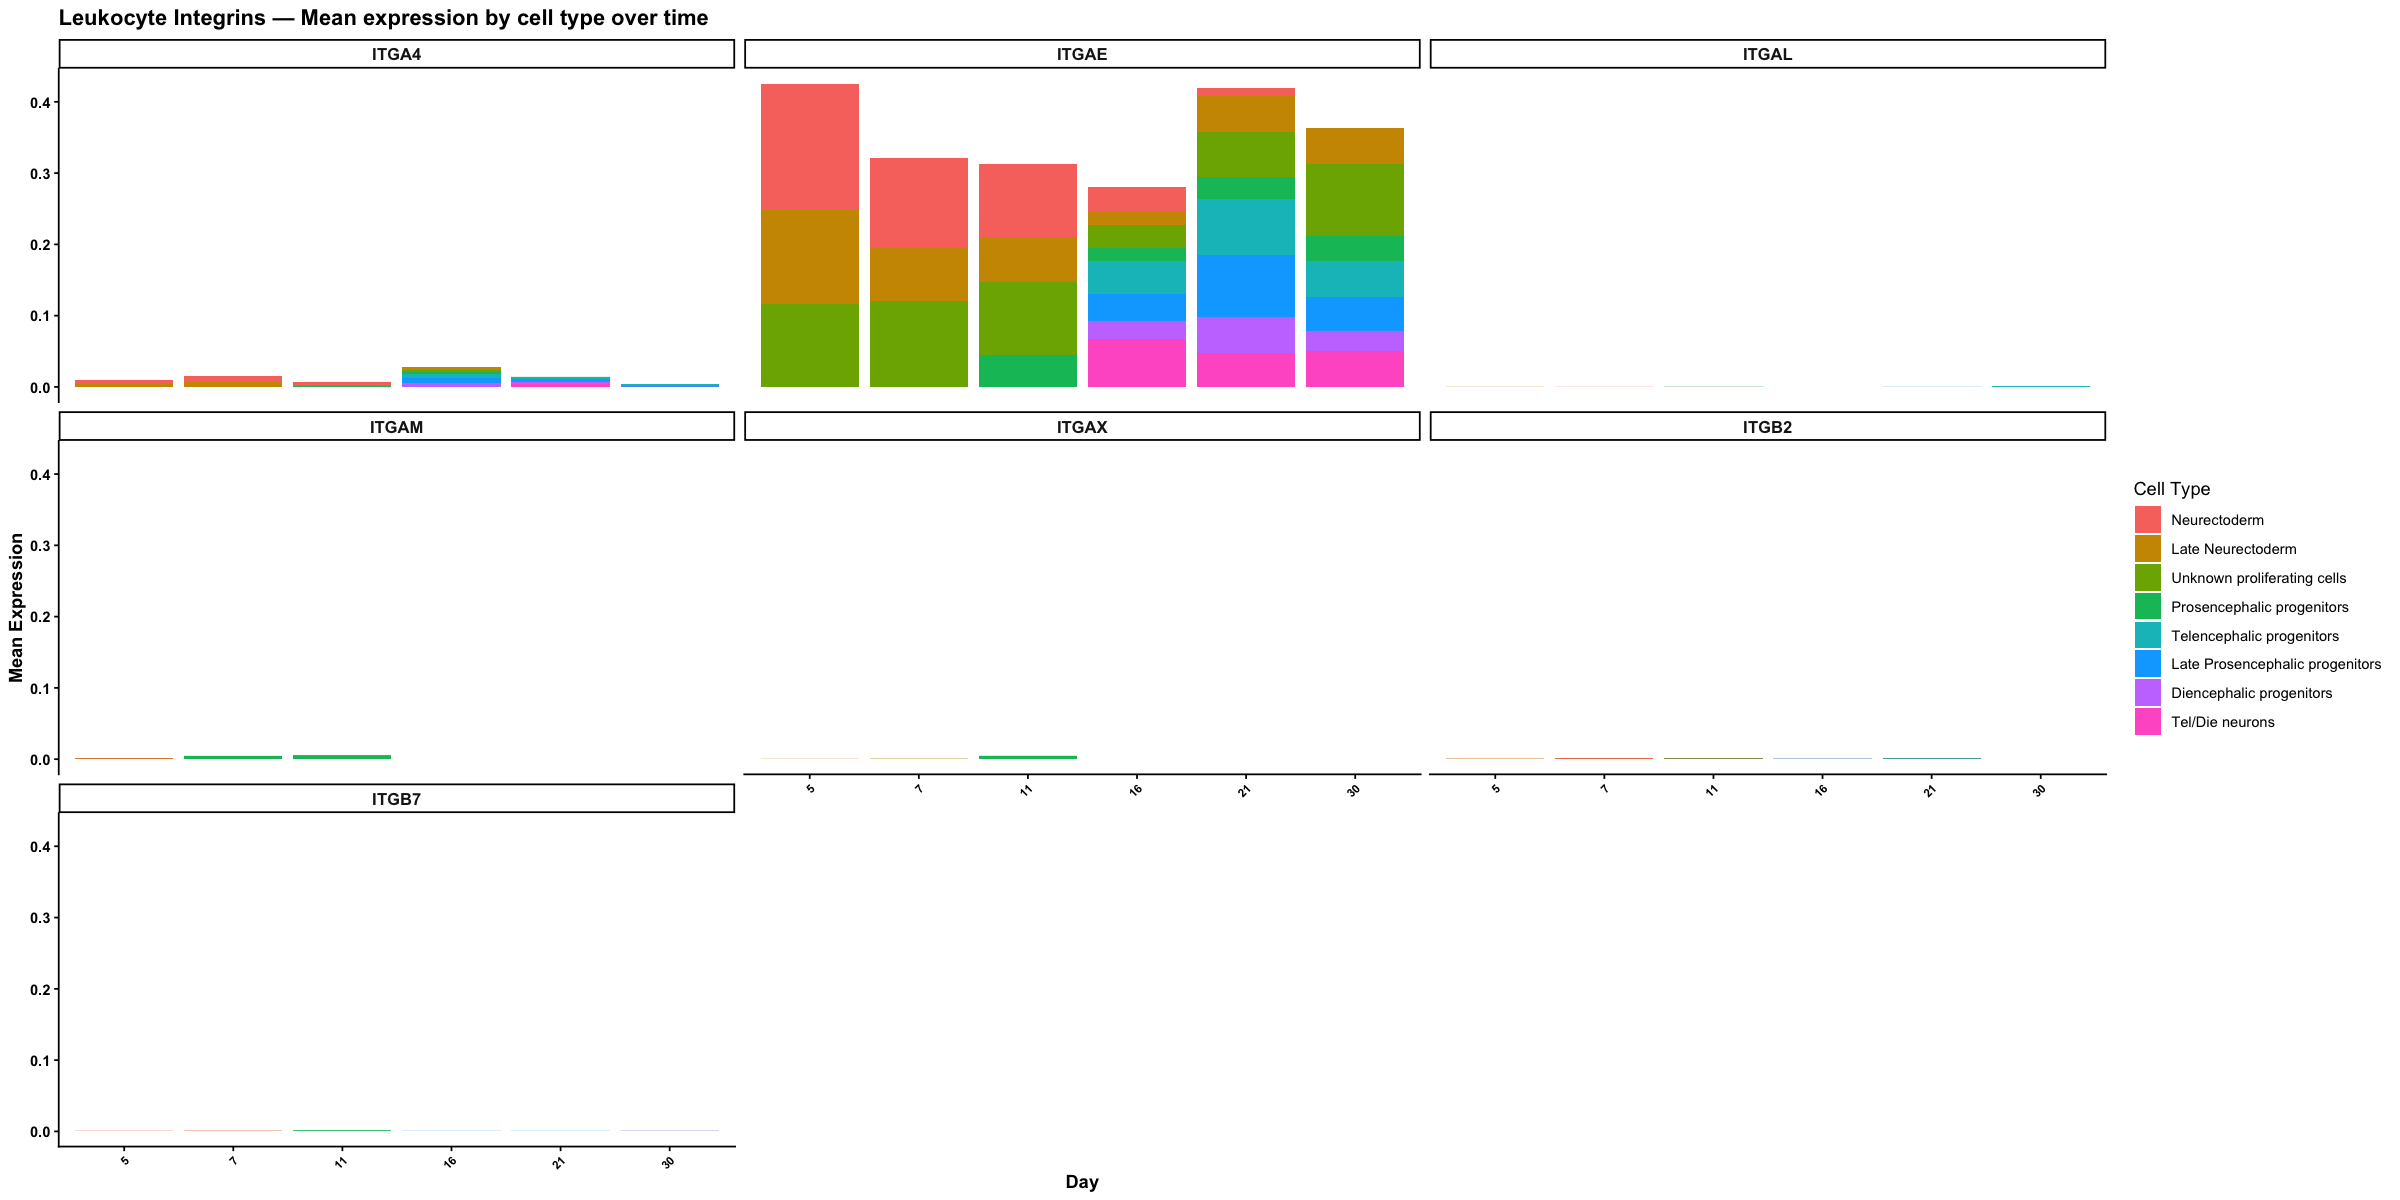

In [ ]:
# leukocyte

leukocyte_genes <- c("ITGAL", "ITGAM", "ITGAX", "ITGAE", "ITGA4", "ITGB2", "ITGB7")
leukocyte_genes <- leukocyte_genes[leukocyte_genes %in% rownames(timecourse)]

all_combined <- data.frame()

for (gene in leukocyte_genes) {
  expr <- GetAssayData(timecourse, layer = "data")[gene, ]
  meta <- timecourse@meta.data
  meta$expr <- expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           gene = gene)
  
  all_combined <- rbind(all_combined, combined)
}

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, scales = "free_y", ncol = 3) +
  labs(title = "Leukocyte Integrins — Mean expression by cell type over time",
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )


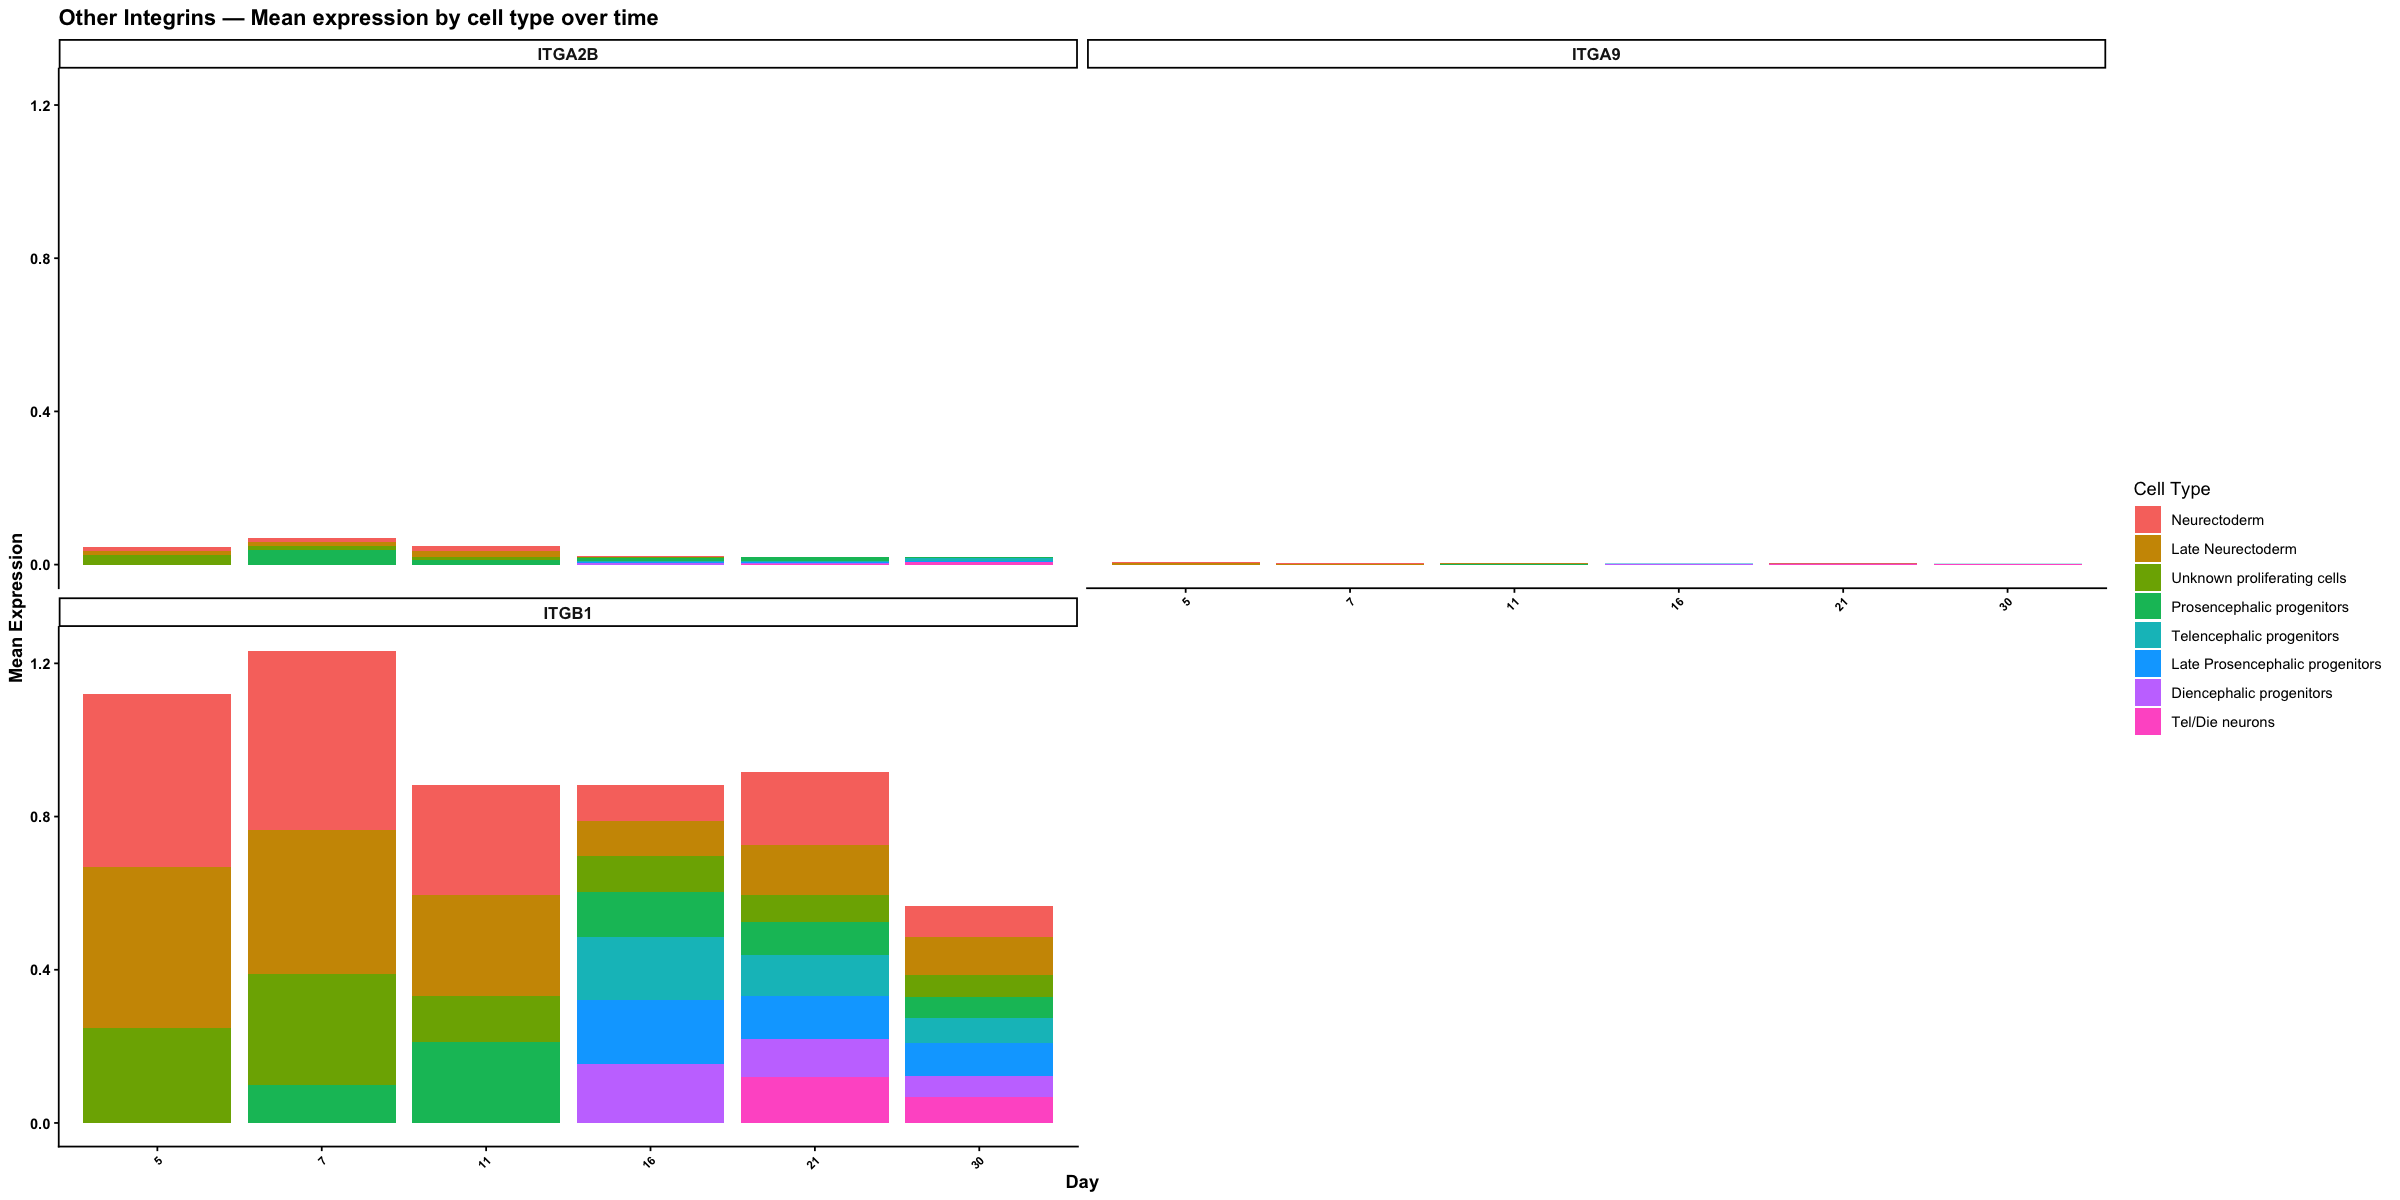

In [124]:
# others

other_genes <- c("ITGA9", "ITGA2B", "ITGB1")
other_genes <- other_genes[other_genes %in% rownames(timecourse)]

all_combined <- data.frame()

for (gene in other_genes) {
  expr <- GetAssayData(timecourse, layer = "data")[gene, ]
  meta <- timecourse@meta.data
  meta$expr <- expr
  
  overall_mean <- meta %>%
    group_by(day) %>%
    summarise(day_mean = mean(expr), .groups = "drop")
  
  expr_mean <- meta %>%
    group_by(day, class3) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    group_by(day) %>%
    mutate(proportion = mean_expr / sum(mean_expr))
  
  combined <- expr_mean %>%
    left_join(overall_mean, by = "day") %>%
    mutate(segment_height = proportion * day_mean,
           gene = gene)
  
  all_combined <- rbind(all_combined, combined)
}

ggplot(all_combined, aes(x = factor(day), y = segment_height, fill = class3)) +
  geom_bar(stat = "identity") +
  facet_wrap(~gene, ncol = 2) +
  labs(title = "Other Integrins — Mean expression by cell type over time",
       x = "Day", y = "Mean Expression", fill = "Cell Type") +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold", size = 10),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7)
  )
